# Modelltraining für Fraud Detection

## 1. Setup und Daten laden

In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model

import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore')

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {tf.config.list_physical_devices('GPU')}")
print("Bibliotheken geladen")

import os
os.environ['PYTHONHASHSEED']=str(42)

/home/enzoz/Hochschule/QKI/GIT/fraudDetection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-13 19:02:10.396382: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 19:02:10.420975: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 19:02:12.380544: I tensorflow/core/util/port.cc:153] one

TensorFlow Version: 2.20.0
GPU verfügbar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Bibliotheken geladen


W0000 00:00:1763056933.076677 2285242 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1763056933.082676 2285242 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1763056933.082676 2285242 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
# GPU komplett deaktivieren (CUDA-Fehler beheben)
print("Deaktiviere GPU und erzwinge CPU-Nutzung...")

# GPU komplett unsichtbar machen für TensorFlow
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Alternative: TensorFlow konfigurieren, keine GPU zu verwenden
tf.config.set_visible_devices([], 'GPU')

print("GPU deaktiviert - verwende nur CPU")
print("Das Training wird langsamer sein, aber stabil laufen")

# Verfügbare Devices anzeigen
print(f"\nVerfügbare Devices: {tf.config.list_physical_devices()}")

Deaktiviere GPU und erzwinge CPU-Nutzung...
GPU deaktiviert - verwende nur CPU
Das Training wird langsamer sein, aber stabil laufen

Verfügbare Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Trainingsdaten laden
train_df = pd.read_pickle('../3. Datenteilung/train.pkl')
validation_df = pd.read_pickle('../3. Datenteilung/validation.pkl')
test_df = pd.read_pickle('../3. Datenteilung/test.pkl')

print("Daten geladen:")
print(f"Training: {train_df.shape}")
print(f"Validation: {validation_df.shape}")
print(f"Test: {test_df.shape}")

# Fraud-Verteilung prüfen
print(f"\nFraud-Verteilung Training:")
print(train_df['Is_Fraud'].value_counts())
print(f"\nFraud-Rate: {train_df['Is_Fraud'].mean()*100:.2f}%")

Daten geladen:
Training: (140000, 21)
Validation: (30000, 21)
Test: (30000, 21)

Fraud-Verteilung Training:
Is_Fraud
0    132938
1      7062
Name: count, dtype: int64

Fraud-Rate: 5.04%


In [4]:
# Features und Labels trennen
X_train = train_df.drop('Is_Fraud', axis=1)
y_train = train_df['Is_Fraud']

X_val = validation_df.drop('Is_Fraud', axis=1)
y_val = validation_df['Is_Fraud']

X_test = test_df.drop('Is_Fraud', axis=1)
y_test = test_df['Is_Fraud']

print(f"Feature-Anzahl: {X_train.shape[1]}")
print(f"\nFeatures: {list(X_train.columns)}")

Feature-Anzahl: 20

Features: ['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description', 'Transaction_Day', 'Transaction_Hour', 'Transaction_Minute', 'Transaction_Second', 'Transaction_To_Balance_Ratio', 'Is_Large_Transaction']


In [5]:
# Feature-Normalisierung (wichtig für NN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features standardisiert")
print(f"Mittelwert: {X_train_scaled.mean():.6f}")
print(f"Standardabweichung: {X_train_scaled.std():.6f}")

Features standardisiert
Mittelwert: 0.000000
Standardabweichung: 1.000000


## 2. Umgang mit Klassenungleichgewicht

**Zwei Ansätze** um das Klassenungleichgewicht zu behandeln:
- **Workflow A**: Class Weights (Original-Daten mit Gewichtung in der Loss-Funktion)
- **Workflow B**: SMOTE (Synthetische Samples generieren für Training)

In [6]:
# Workflow A: Class Weights berechnen
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("=" * 80)
print("WORKFLOW A: CLASS WEIGHTS")
print("=" * 80)
print(f"Legitim (0): {class_weight_dict[0]:.2f}")
print(f"Betrug (1): {class_weight_dict[1]:.2f}")
print(f"Ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}:1")
print(f"Trainingsdaten: {X_train_scaled.shape}")

WORKFLOW A: CLASS WEIGHTS
Legitim (0): 0.53
Betrug (1): 9.91
Ratio: 18.82:1
Trainingsdaten: (140000, 20)


## 3. WORKFLOW A: Modelle OHNE SMOTE (mit Class Weights)

Wir trainieren verschiedene Modellarchitekturen mit den Original-Daten und Class Weights.

### 3.1 Baseline-Modell (Class Weights)

In [7]:
def create_baseline_model(input_dim, learning_rate=0.001):
    """
    Einfaches Baseline-Modell
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

# Modell erstellen und anzeigen
baseline_model = create_baseline_model(X_train_scaled.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Callbacks definieren
early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'baseline_model_best.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks definiert")

Callbacks definiert


In [10]:
# Baseline-Modell trainieren (OHNE SMOTE, mit Class Weights)
print("=" * 80)
print("WORKFLOW A: Training Baseline-Modell mit Class Weights")
print("=" * 80)
print()

history_baseline_cw = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1,
)

print("\nTraining abgeschlossen")

WORKFLOW A: Training Baseline-Modell mit Class Weights

Epoch 1/100


2025-11-13 19:02:30.843974: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ea17800cb60 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 19:02:30.843984: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 19:02:30.863918: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


365/547 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step - accuracy: 0.5171 - auc: 0.4992 - loss: 0.7144 - precision: 0.0505 - recall: 0.4807

I0000 00:00:1763056951.119586 2285373 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.5083 - auc: 0.4994 - loss: 0.7117 - precision: 0.0505 - recall: 0.4907
Epoch 1: val_auc improved from None to 0.51423, saving model to baseline_model_best.h5

Epoch 1: val_auc improved from None to 0.51423, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4868 - auc: 0.4996 - loss: 0.7033 - precision: 0.0504 - recall: 0.5137 - val_accuracy: 0.5773 - val_auc: 0.5142 - val_loss: 0.6873 - val_precision: 0.0516 - val_recall: 0.4250 - learning_rate: 0.0010
Epoch 2/100
Epoch 2/100
522/547 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.5234 - auc: 0.5064 - loss: 0.6981 - precision: 0.0515 - recall: 0.4811
Epoch 2: val_auc improved from 0.51423 to 0.51771, saving model to baseline_model_best.h5

Epoch 2: val_auc improved from 0.51423 to 0.51771, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.5034 - auc: 0.5052 - loss: 0.6946 - precision: 0.0507 - recall: 0.4990 - val_accuracy: 0.3938 - val_auc: 0.5177 - val_loss: 0.6983 - val_precision: 0.0515 - val_recall: 0.6325 - learning_rate: 0.0010
Epoch 3/100
Epoch 3/100
521/547 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - accuracy: 0.4328 - auc: 0.5133 - loss: 0.7004 - precision: 0.0537 - recall: 0.6026
Epoch 3: val_auc did not improve from 0.51771
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.4641 - auc: 0.5117 - loss: 0.6935 - precision: 0.0521 - recall: 0.5600 - val_accuracy: 0.6420 - val_auc: 0.5086 - val_loss: 0.6867 - val_precision: 0.0533 - val_recall: 0.3642 - learning_rate: 0.0010
Epoch 4/100

Epoch 3: val_auc did not improve from 0.51771
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.4641 - auc: 0.5117 - loss: 0.6935 - precision: 0.0521 - recall: 0.5600 - val_accuracy: 0.6420 - val_auc: 0.5086 - val_loss: 0.6867 - val_precision: 0.0533 - val_recall: 0.3

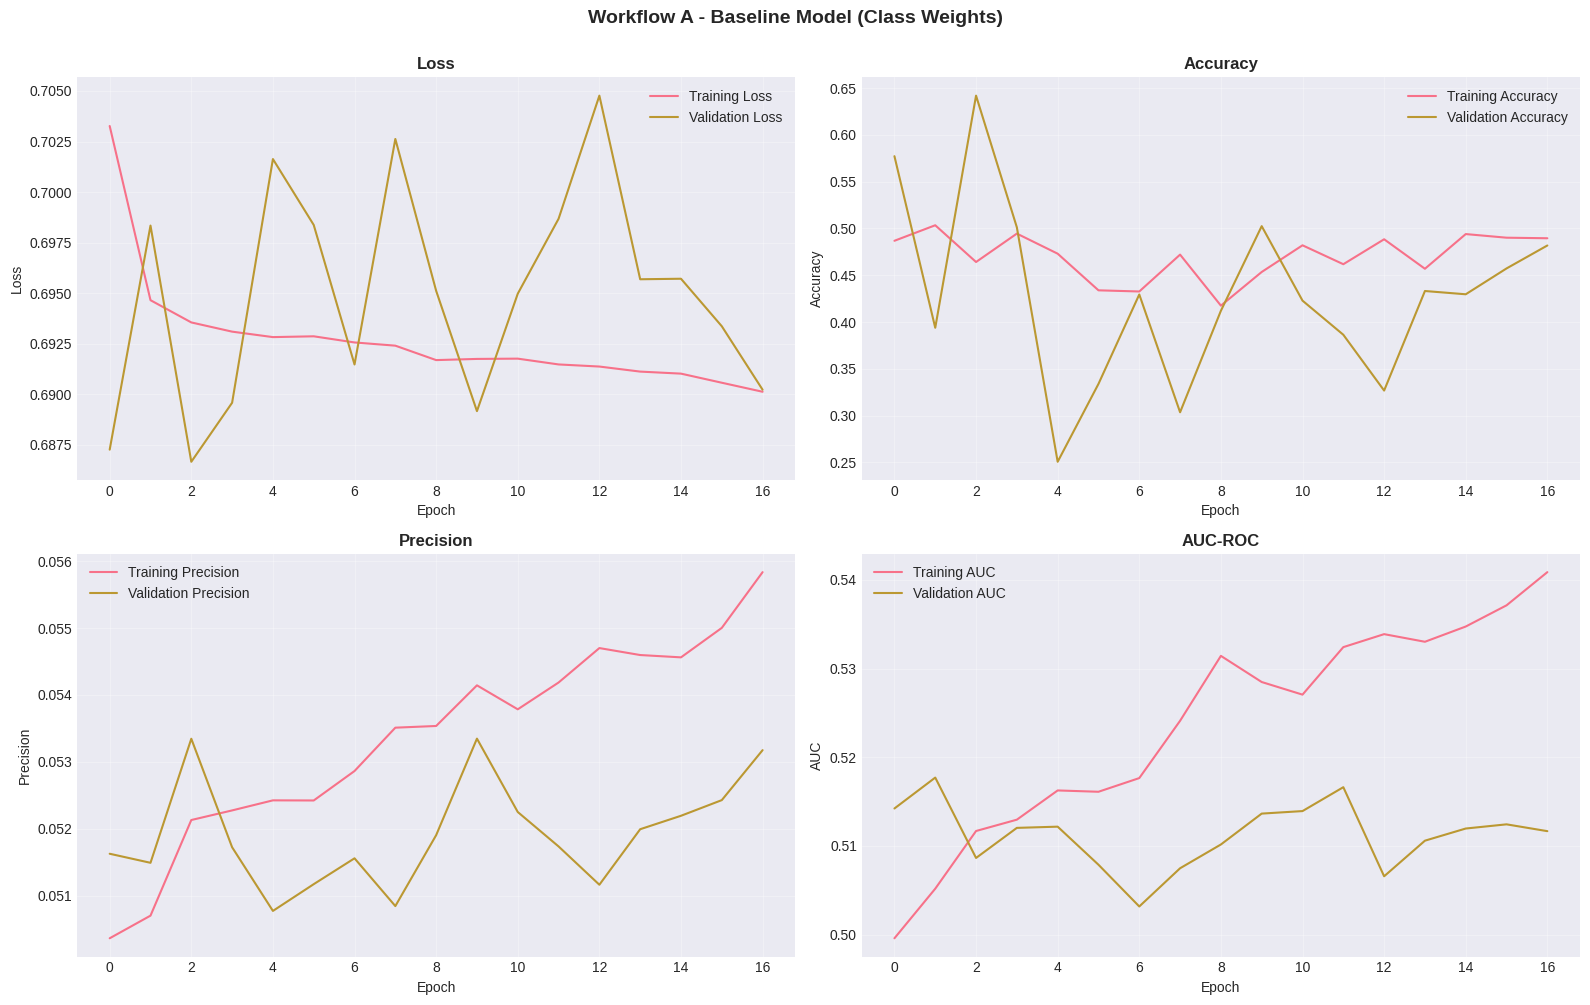

In [11]:
# Training-History visualisieren
def plot_training_history(history, title="Training History"):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Loss', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 1].set_title('Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Precision', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # AUC
    axes[1, 1].plot(history.history['auc'], label='Training AUC')
    axes[1, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1, 1].set_title('AUC-ROC', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

plot_training_history(history_baseline_cw, "Workflow A - Baseline Model (Class Weights)")

### 3.2 Model Evaluation

In [14]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Gibt nur Accuracy (gesamt) und Recall der Betrugsklasse (Label=1) aus.
    """
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).ravel()

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_test, y_pred)
    recall_fraud = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    print("=" * 80)
    print(f"EVALUATION: {model_name}")
    print("=" * 80)
    print(f"Recall (Fraud-Klasse = 1): {recall_fraud:.4f}")

    return {
        'accuracy': accuracy,
        'recall_fraud': recall_fraud
    }

# Baseline-Modell evaluieren (Class Weights)
baseline_cw_results = evaluate_model(baseline_model, X_test_scaled, y_test, "Workflow A - Baseline (Class Weights)")


EVALUATION: Workflow A - Baseline (Class Weights)
Recall (Fraud-Klasse = 1): 0.6259


### 3.3 Hyperparameter-Optimierung (Class Weights)

In [12]:
def build_tuner_model(hp):
    """
    Modell-Builder für Keras Tuner
    """
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    
    # Anzahl der Hidden Layers
    num_layers = hp.Int('num_layers', min_value=2, max_value=5, step=1)
    
    for i in range(num_layers):
        # Neuronen pro Layer
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        model.add(layers.Dense(units, activation='relu'))
        
        # Dropout
        dropout = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
        model.add(layers.Dropout(dropout))
    
    # Output Layer
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Learning Rate
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

print("Tuner-Model-Builder definiert")

Tuner-Model-Builder definiert


In [13]:
# Keras Tuner initialisieren (Bayesian Optimization) - Workflow A
tuner_cw = kt.BayesianOptimization(
    build_tuner_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=20,  # Anzahl verschiedener Konfigurationen
    executions_per_trial=1,
    directory='tuner_results_class_weights',
    project_name='fraud_detection_cw',
    overwrite=True
)

print("=" * 80)
print("WORKFLOW A: Hyperparameter-Tuning mit Class Weights")
print("=" * 80)
print("\nTuner Search Space:")
tuner_cw.search_space_summary()

WORKFLOW A: Hyperparameter-Tuning mit Class Weights

Tuner Search Space:
Search space summary
Default search space size: 6
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [14]:
# Hyperparameter-Suche starten (Class Weights)
print("Starte Hyperparameter-Suche (Workflow A: Class Weights)...\n")

stop_early = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max'
)

tuner_cw.search(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[stop_early],
    verbose=1
)

print("\nHyperparameter-Suche abgeschlossen (Workflow A)")

Trial 20 Complete [00h 00m 14s]
val_auc: 0.5204147100448608

Best val_auc So Far: 0.5219429731369019
Total elapsed time: 00h 03m 14s

Hyperparameter-Suche abgeschlossen (Workflow A)


In [15]:
# Beste Hyperparameter anzeigen (Workflow A)
best_hps_cw = tuner_cw.get_best_hyperparameters(num_trials=1)[0]

print("=" * 80)
print("BESTE HYPERPARAMETER (Workflow A: Class Weights)")
print("=" * 80)
print(f"Anzahl Layer: {best_hps_cw.get('num_layers')}")
print(f"Learning Rate: {best_hps_cw.get('learning_rate')}")
print("\nLayer-Konfiguration:")
for i in range(best_hps_cw.get('num_layers')):
    print(f"  Layer {i+1}: {best_hps_cw.get(f'units_{i}')} Units, Dropout: {best_hps_cw.get(f'dropout_{i}')}")

BESTE HYPERPARAMETER (Workflow A: Class Weights)
Anzahl Layer: 4
Learning Rate: 0.001

Layer-Konfiguration:
  Layer 1: 32 Units, Dropout: 0.30000000000000004
  Layer 2: 256 Units, Dropout: 0.1
  Layer 3: 160 Units, Dropout: 0.30000000000000004
  Layer 4: 192 Units, Dropout: 0.4


In [17]:
# Top 5 Modelle anzeigen (Workflow A)
print("Top 5 Modelle (Workflow A):")
tuner_cw.results_summary(num_trials=5)

Top 5 Modelle (Workflow A):
Results summary
Results in tuner_results_class_weights/fraud_detection_cw
Showing 5 best trials
Objective(name="val_auc", direction="max")

Trial 01 summary
Hyperparameters:
num_layers: 2
units_0: 96
dropout_0: 0.1
units_1: 256
dropout_1: 0.2
learning_rate: 0.0001
units_2: 96
dropout_2: 0.1
units_3: 256
dropout_3: 0.5
units_4: 96
dropout_4: 0.1
Score: 0.5251493453979492

Trial 07 summary
Hyperparameters:
num_layers: 2
units_0: 192
dropout_0: 0.4
units_1: 96
dropout_1: 0.2
learning_rate: 0.001
units_2: 96
dropout_2: 0.30000000000000004
units_3: 224
dropout_3: 0.4
units_4: 64
dropout_4: 0.1
Score: 0.5217623710632324

Trial 11 summary
Hyperparameters:
num_layers: 4
units_0: 160
dropout_0: 0.1
units_1: 192
dropout_1: 0.5
learning_rate: 0.0001
units_2: 32
dropout_2: 0.1
units_3: 160
dropout_3: 0.1
units_4: 256
dropout_4: 0.1
Score: 0.5207309722900391

Trial 18 summary
Hyperparameters:
num_layers: 2
units_0: 128
dropout_0: 0.2
units_1: 160
dropout_1: 0.5
learning_

In [16]:
# Bestes Modell laden und trainieren (Workflow A)
best_model_cw = tuner_cw.hypermodel.build(best_hps_cw)

print("=" * 80)
print("Training des besten Modells (Workflow A: Class Weights)")
print("=" * 80)
print()

history_best_cw = best_model_cw.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
        callbacks.ModelCheckpoint('best_tuned_model_cw.h5', monitor='val_auc', save_best_only=True, mode='max')
    ],
    verbose=1
)

print("\nTraining abgeschlossen (Workflow A)")

Training des besten Modells (Workflow A: Class Weights)

Epoch 1/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4868 - auc: 0.5011 - loss: 0.7051 - precision: 0.0513 - recall: 0.5155  

547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4883 - auc: 0.4964 - loss: 0.6974 - precision: 0.0499 - recall: 0.5072 - val_accuracy: 0.6318 - val_auc: 0.4905 - val_loss: 0.6885 - val_precision: 0.0510 - val_recall: 0.3576 - learning_rate: 0.0010
Epoch 2/100
Epoch 2/100
511/547 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.5380 - auc: 0.5101 - loss: 0.6886 - precision: 0.0517 - recall: 0.4792

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5088 - auc: 0.5060 - loss: 0.6939 - precision: 0.0511 - recall: 0.4977 - val_accuracy: 0.4180 - val_auc: 0.5078 - val_loss: 0.6959 - val_precision: 0.0517 - val_recall: 0.6081 - learning_rate: 0.0010
Epoch 3/100
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4582 - auc: 0.5019 - loss: 0.6938 - precision: 0.0505 - recall: 0.5472 - val_accuracy: 0.8561 - val_auc: 0.4913 - val_loss: 0.6744 - val_precision: 0.0512 - val_recall: 0.1058 - learning_rate: 0.0010
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4582 - auc: 0.5019 - loss: 0.6938 - precision: 0.0505 - recall: 0.5472 - val_accuracy: 0.8561 - val_auc: 0.4913 - val_loss: 0.6744 - val_precision: 0.0512 - val_recall: 0.1058 - learning_rate: 0.0010
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5356 - auc: 0.5105 - loss: 0.6934 - precision: 0.0521 - recall: 0.4769 - val_accuracy: 0.8223 - val_auc: 0.4949 - val_loss: 0.6846 -

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5592 - auc: 0.5132 - loss: 0.6932 - precision: 0.0527 - recall: 0.4554 - val_accuracy: 0.7729 - val_auc: 0.5110 - val_loss: 0.6837 - val_precision: 0.0539 - val_recall: 0.2115 - learning_rate: 0.0010
Epoch 6/100
Epoch 6/100
497/547 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.6354 - auc: 0.5084 - loss: 0.6858 - precision: 0.0515 - recall: 0.3659

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5807 - auc: 0.5056 - loss: 0.6935 - precision: 0.0509 - recall: 0.4145 - val_accuracy: 0.5106 - val_auc: 0.5176 - val_loss: 0.6954 - val_precision: 0.0528 - val_recall: 0.5135 - learning_rate: 0.0010
Epoch 7/100
Epoch 7/100
507/547 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.4206 - auc: 0.5172 - loss: 0.6966 - precision: 0.0530 - recall: 0.6141

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4835 - auc: 0.5135 - loss: 0.6929 - precision: 0.0521 - recall: 0.5378 - val_accuracy: 0.6717 - val_auc: 0.5239 - val_loss: 0.6902 - val_precision: 0.0558 - val_recall: 0.3457 - learning_rate: 0.0010
Epoch 8/100
Epoch 8/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5620 - auc: 0.5075 - loss: 0.6933 - precision: 0.0516 - recall: 0.4421 - val_accuracy: 0.9012 - val_auc: 0.5111 - val_loss: 0.6761 - val_precision: 0.0530 - val_recall: 0.0568 - learning_rate: 0.0010
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5620 - auc: 0.5075 - loss: 0.6933 - precision: 0.0516 - recall: 0.4421 - val_accuracy: 0.9012 - val_auc: 0.5111 - val_loss: 0.6761 - val_precision: 0.0530 - val_recall: 0.0568 - learning_rate: 0.0010
Epoch 9/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6176 - auc: 0.5145 - loss: 0.6928 - precision: 0.0523 - recall: 0.3840 - val_accuracy: 0.7999 - val_auc: 0.5062 - val_loss: 0.6822 -

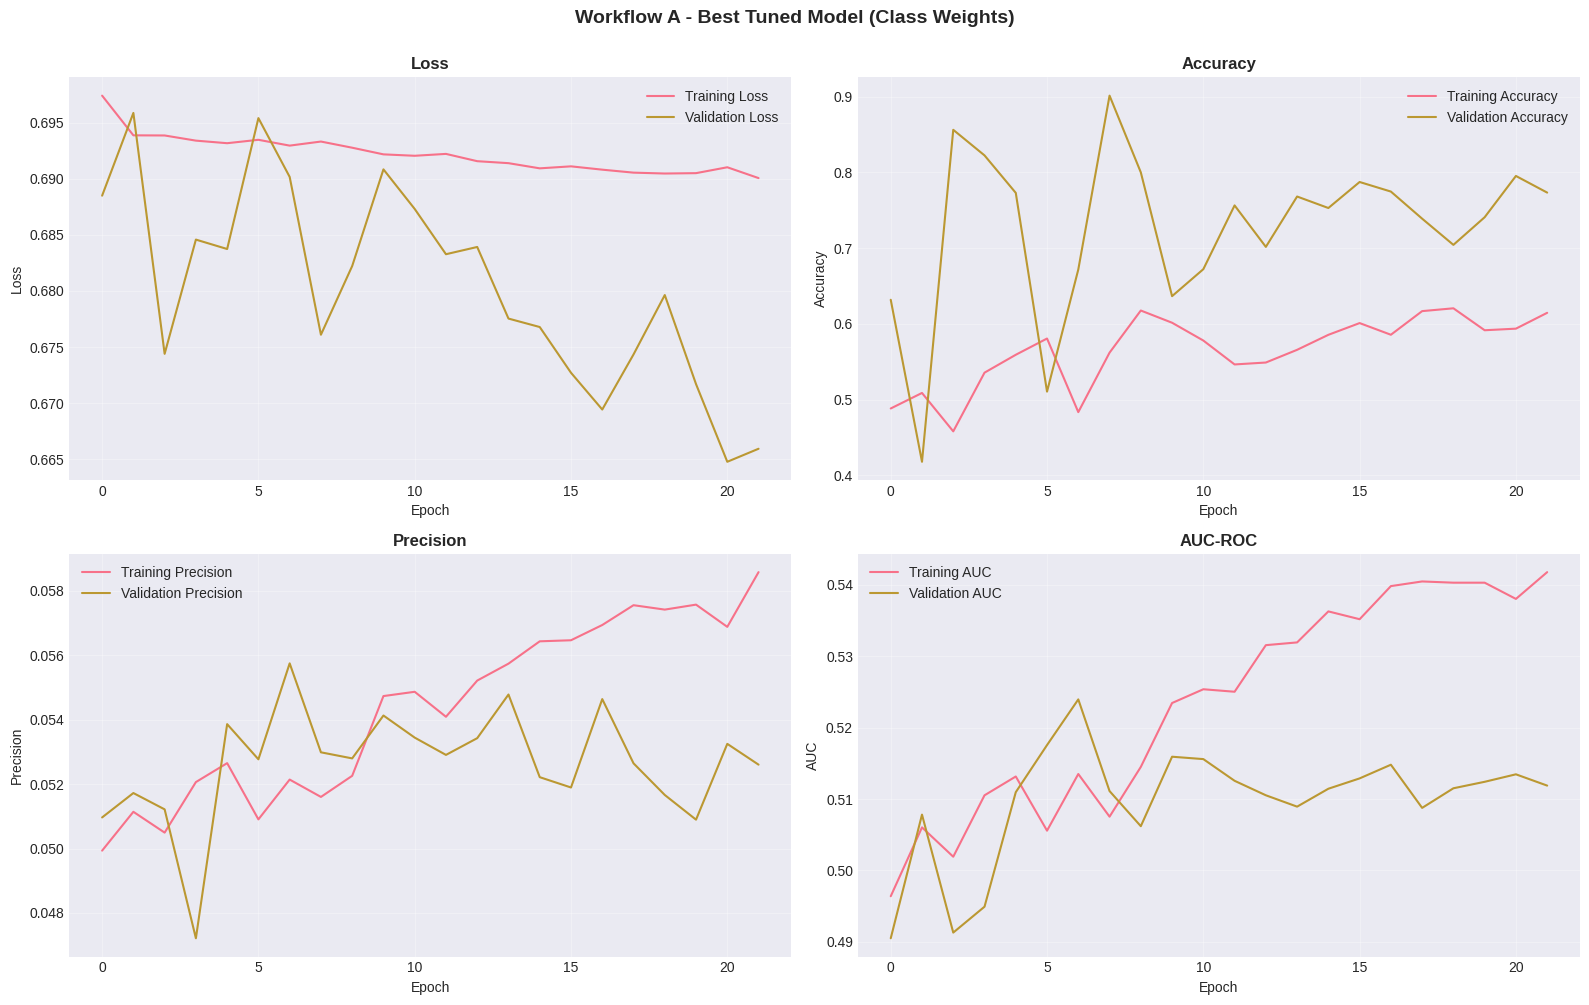

In [17]:
# Training History visualisieren (Workflow A)
plot_training_history(history_best_cw, "Workflow A - Best Tuned Model (Class Weights)")

EVALUATION: Workflow A - Best Tuned (Class Weights)

Classification Report:
              precision    recall  f1-score   support

     Legitim       0.95      0.69      0.80     28487
      Betrug       0.05      0.31      0.09      1513

    accuracy                           0.67     30000
   macro avg       0.50      0.50      0.44     30000
weighted avg       0.90      0.67      0.76     30000

AUC-ROC Score: 0.5056


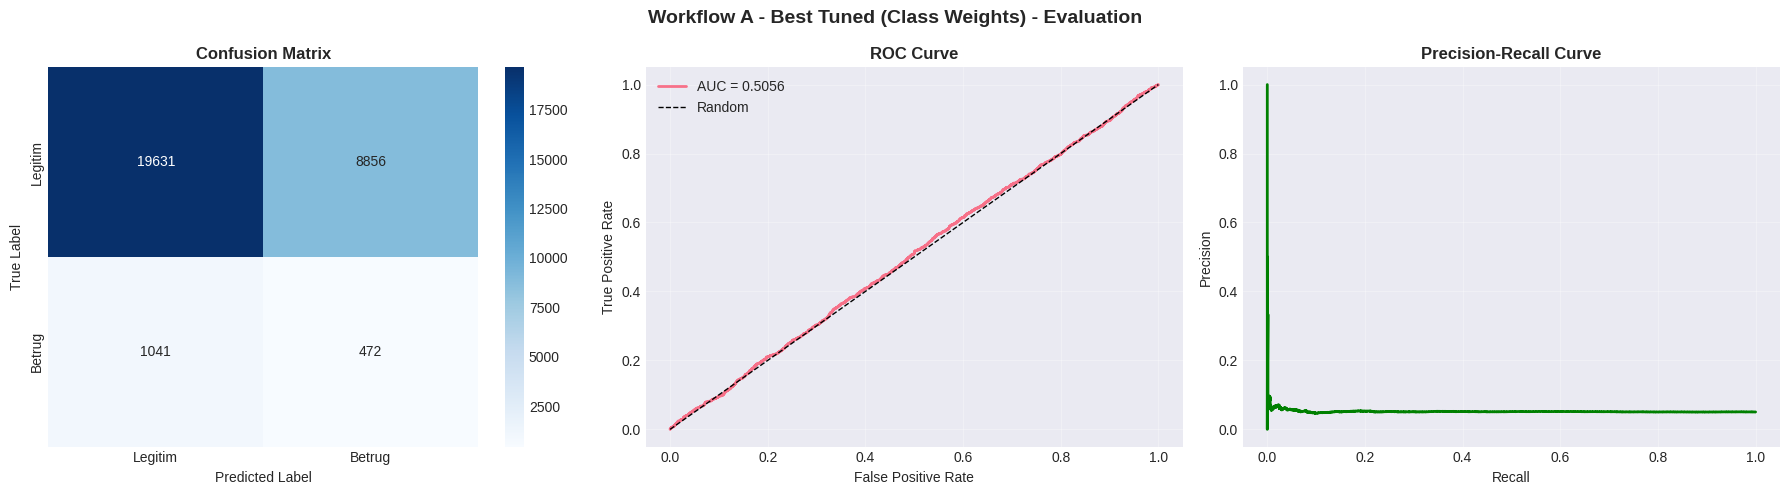


Zusätzliche Metriken:
True Negatives: 19631
False Positives: 8856
False Negatives: 1041
True Positives: 472
Specificity (True Negative Rate): 0.6891
Sensitivity (True Positive Rate/Recall): 0.3120


In [18]:
# Bestes Modell evaluieren (Workflow A)
best_model_cw_results = evaluate_model(best_model_cw, X_test_scaled, y_test, "Workflow A - Best Tuned (Class Weights)")

### 3.4 Alternative Architektur: Deep Network (Class Weights)

In [21]:
def create_deep_model(input_dim):
    """
    Tiefes neuronales Netzwerk
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Layer 1
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        # Layer 2
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Layer 3
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Layer 4
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        # Output
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

deep_model = create_deep_model(X_train_scaled.shape[1])
deep_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,561 (197.50 KB)

 Trainable params: 49,601 (193.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
# Deep Model trainieren (Workflow A: Class Weights)
print("=" * 80)
print("WORKFLOW A: Training Deep Model (Class Weights)")
print("=" * 80)
print()

history_deep_cw = deep_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
        callbacks.ModelCheckpoint('deep_model_cw.h5', monitor='val_auc', save_best_only=True, mode='max')
    ],
    verbose=1
)

print("\n✓ Training abgeschlossen (Workflow A)")

WORKFLOW A: Training Deep Model (Class Weights)

Epoch 1/100


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4893 - auc: 0.5003 - loss: 0.8364 - precision: 0.0503 - recall: 0.5113

547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4946 - auc: 0.4997 - loss: 0.7768 - precision: 0.0501 - recall: 0.5020 - val_accuracy: 0.4997 - val_auc: 0.5063 - val_loss: 0.6972 - val_precision: 0.0505 - val_recall: 0.5017 - learning_rate: 0.0010
Epoch 2/100
523/547 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5009 - auc: 0.5056 - loss: 0.7206 - precision: 0.0516 - recall: 0.5096

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4964 - auc: 0.5067 - loss: 0.7129 - precision: 0.0513 - recall: 0.5133 - val_accuracy: 0.6156 - val_auc: 0.5075 - val_loss: 0.6854 - val_precision: 0.0521 - val_recall: 0.3853 - learning_rate: 0.0010
Epoch 3/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4969 - auc: 0.5035 - loss: 0.7007 - precision: 0.0510 - recall: 0.5095 - val_accuracy: 0.4261 - val_auc: 0.4987 - val_loss: 0.6999 - val_precision: 0.0513 - val_recall: 0.5929 - learning_rate: 0.0010
Epoch 4/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5049 - auc: 0.5039 - loss: 0.6969 - precision: 0.0508 - recall: 0.4987 - val_accuracy: 0.4205 - val_auc: 0.4979 - val_loss: 0.6989 - val_precision: 0.0505 - val_recall: 0.5896 - learning_rate: 0.0010
Epoch 5/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4925 - auc: 0.5151 - loss: 0.6939 - precision: 0.0523 - recall: 0.5292 - val_accuracy: 0.6689 - val_auc: 0.4976 - val_loss: 0.6842 - val_precisi

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5052 - auc: 0.5308 - loss: 0.6917 - precision: 0.0546 - recall: 0.5396 - val_accuracy: 0.4887 - val_auc: 0.5080 - val_loss: 0.6926 - val_precision: 0.0520 - val_recall: 0.5307 - learning_rate: 5.0000e-04
Epoch 13/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4927 - auc: 0.5345 - loss: 0.6913 - precision: 0.0555 - recall: 0.5653 - val_accuracy: 0.5090 - val_auc: 0.5039 - val_loss: 0.6892 - val_precision: 0.0511 - val_recall: 0.4970 - learning_rate: 5.0000e-04
Epoch 14/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5282 - auc: 0.5339 - loss: 0.6914 - precision: 0.0557 - recall: 0.5234 - val_accuracy: 0.4820 - val_auc: 0.4994 - val_loss: 0.6911 - val_precision: 0.0500 - val_recall: 0.5155 - learning_rate: 5.0000e-04
Epoch 15/100
547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4997 - auc: 0.5371 - loss: 0.6909 - precision: 0.0553 - recall: 0.5548 - val_accuracy: 0.5228 - val_auc: 0.5023 - val_loss: 0.689

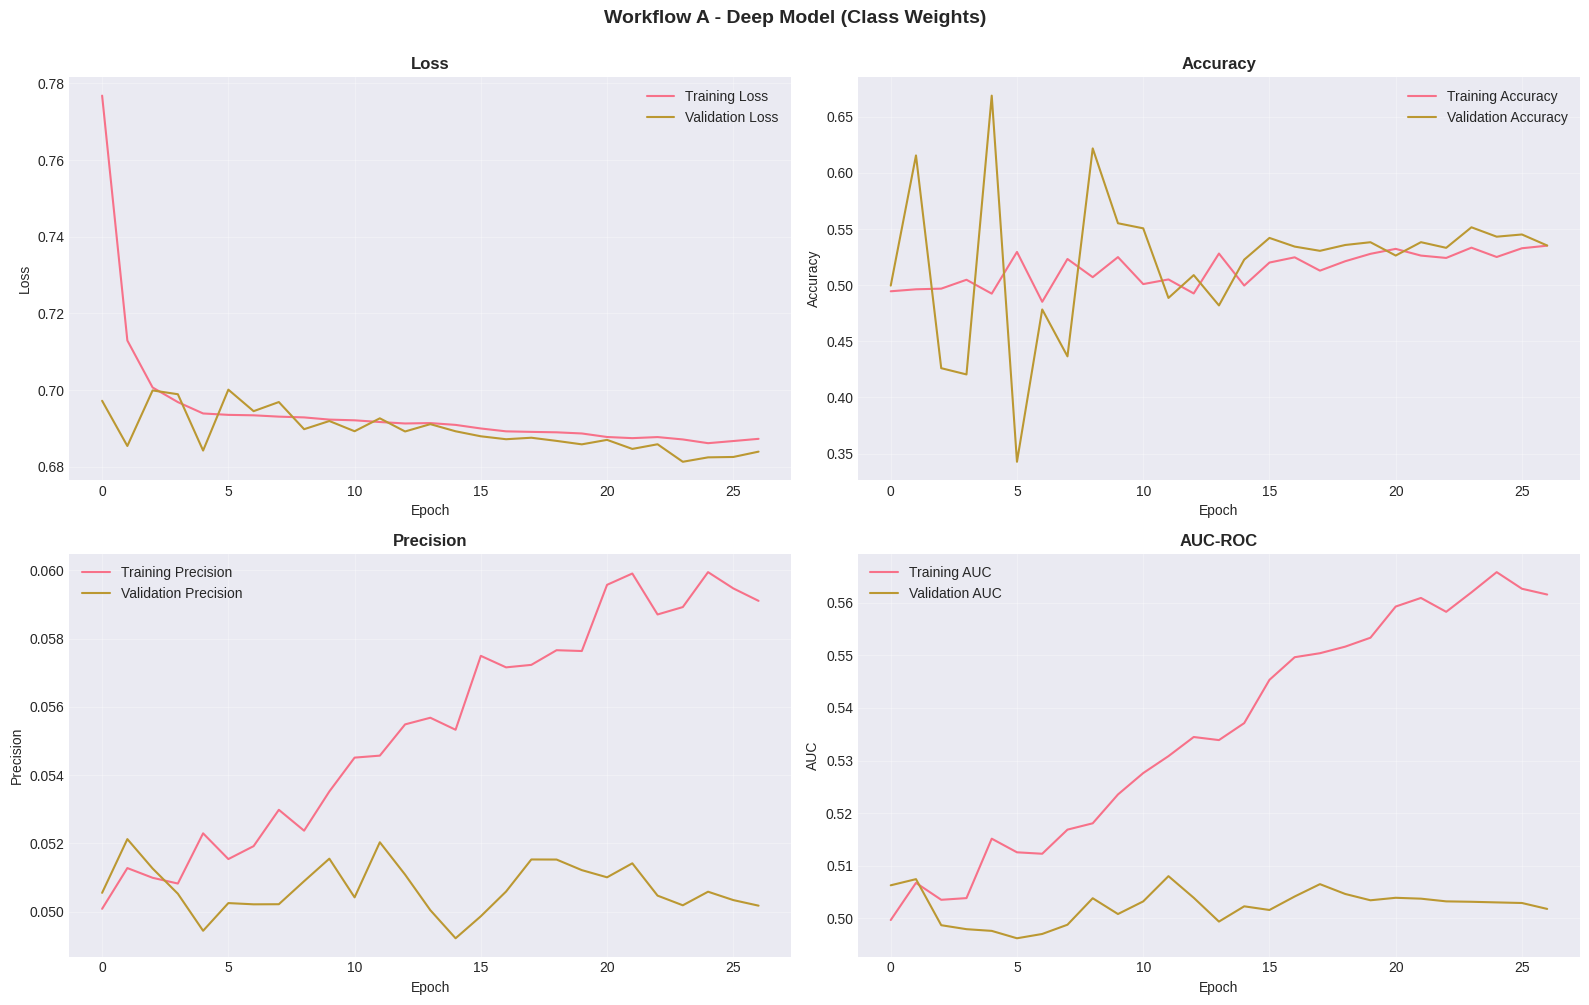

In [23]:
# Training History visualisieren (Workflow A)
plot_training_history(history_deep_cw, "Workflow A - Deep Model (Class Weights)")

EVALUATION: Workflow A - Deep Model (Class Weights)

Classification Report:
              precision    recall  f1-score   support

     Legitim       0.95      0.49      0.64     28487
      Betrug       0.05      0.50      0.09      1513

    accuracy                           0.49     30000
   macro avg       0.50      0.49      0.37     30000
weighted avg       0.90      0.49      0.61     30000

AUC-ROC Score: 0.4951


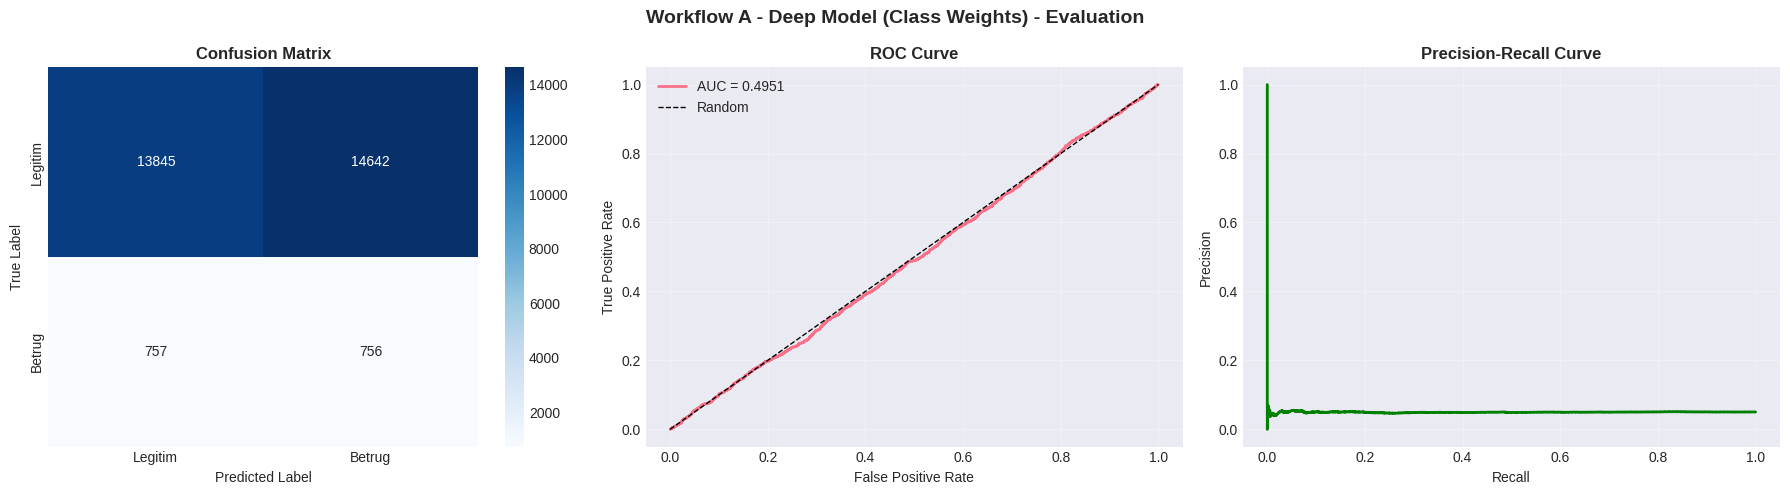


Zusätzliche Metriken:
True Negatives: 13845
False Positives: 14642
False Negatives: 757
True Positives: 756
Specificity (True Negative Rate): 0.4860
Sensitivity (True Positive Rate/Recall): 0.4997


In [24]:
# Deep Model evaluieren (Workflow A)
deep_cw_results = evaluate_model(deep_model, X_test_scaled, y_test, "Workflow A - Deep Model (Class Weights)")

## 4. WORKFLOW B: Modelle MIT SMOTE

### 4.1 SMOTE anwenden auf Trainingsdaten

In [25]:
# SMOTE auf Trainingsdaten anwenden
print("=" * 80)
print("WORKFLOW B: Anwendung von SMOTE")
print("=" * 80)
print()

print("Original Trainingsdaten:")
print(f"  Klasse 0 (Legitim): {sum(y_train == 0):,}")
print(f"  Klasse 1 (Fraud): {sum(y_train == 1):,}")
print(f"  Verhältnis: {sum(y_train == 0) / sum(y_train == 1):.2f}:1")

# SMOTE mit sampling_strategy=0.5 (Ziel: Fraud wird auf 50% der Legitim-Klasse erhöht)
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nNach SMOTE:")
print(f"  Klasse 0 (Legitim): {sum(y_train_smote == 0):,}")
print(f"  Klasse 1 (Fraud): {sum(y_train_smote == 1):,}")
print(f"  Verhältnis: {sum(y_train_smote == 0) / sum(y_train_smote == 1):.2f}:1")
print(f"\nSMOTE erfolgreich angewendet")

WORKFLOW B: Anwendung von SMOTE

Original Trainingsdaten:
  Klasse 0 (Legitim): 132,938
  Klasse 1 (Fraud): 7,062
  Verhältnis: 18.82:1

Nach SMOTE:
  Klasse 0 (Legitim): 132,938


  Klasse 1 (Fraud): 66,469
  Verhältnis: 2.00:1

SMOTE erfolgreich angewendet


### 4.2 Baseline Model MIT SMOTE

In [26]:
# Baseline Model für SMOTE Workflow
baseline_smote = create_baseline_model(X_train.shape[1])
print("=" * 80)
print("WORKFLOW B: Training Baseline Model (SMOTE)")
print("=" * 80)
print()

history_baseline_smote = baseline_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
    ],
    verbose=1
)

print("\nTraining abgeschlossen (Workflow B - Baseline)")

WORKFLOW B: Training Baseline Model (SMOTE)

Epoch 1/100


779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6640 - auc: 0.5516 - loss: 0.6351 - precision: 0.3240 - recall: 0.0073 - val_accuracy: 0.9496 - val_auc: 0.5009 - val_loss: 0.4599 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.6667 - auc: 0.5951 - loss: 0.6240 - precision: 0.5000 - recall: 1.0531e-04 - val_accuracy: 0.9496 - val_auc: 0.5000 - val_loss: 0.4655 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step - accuracy: 0.6672 - auc: 0.6194 - loss: 0.6168 - precision: 0.5732 - recall: 0.0068 - val_accuracy: 0.9483 - val_auc: 0.4995 - val_loss: 0.4421 - val_precision: 0.0667 - val_recall: 0.0020 - learning_rate: 0.0010
Epoch 4/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.6695 - auc: 0.6349 - loss: 0.6112 - precision: 0.5730 - recall: 0.0330 - val_accuracy: 0.9448 - val_auc: 0.4977 - val_

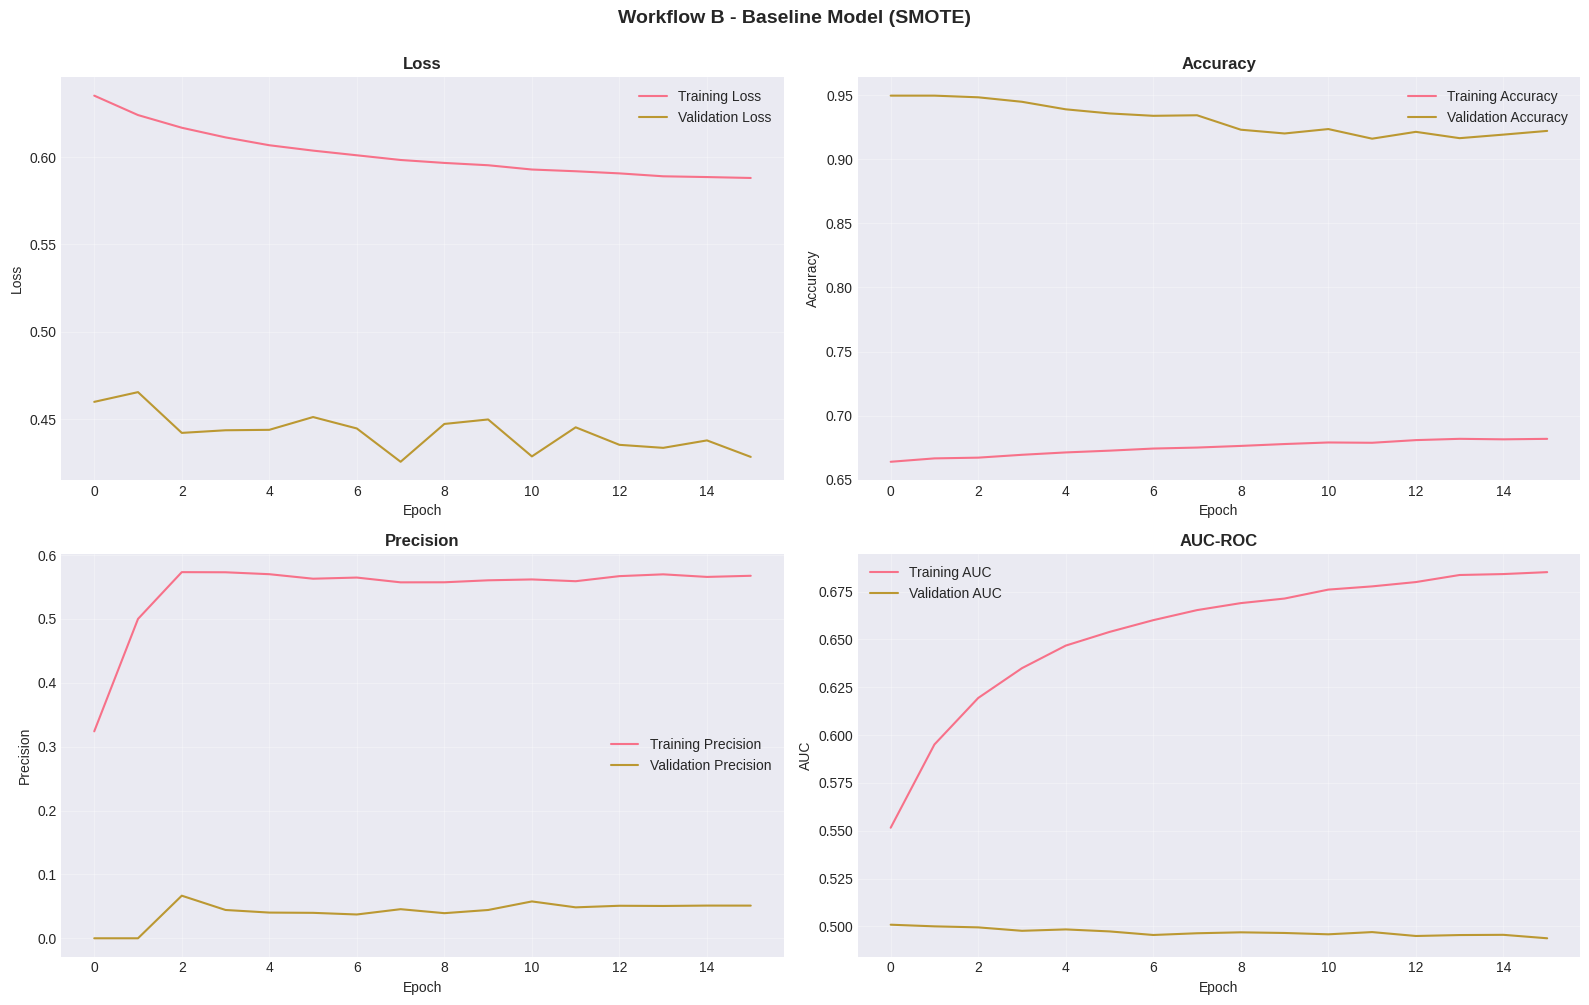

In [27]:
# Training History visualisieren (Workflow B - Baseline)
plot_training_history(history_baseline_smote, "Workflow B - Baseline Model (SMOTE)")

EVALUATION: Workflow B - Baseline Model (SMOTE)

Classification Report:
              precision    recall  f1-score   support

     Legitim       0.95      1.00      0.97     28487
      Betrug       0.00      0.00      0.00      1513

    accuracy                           0.95     30000
   macro avg       0.47      0.50      0.49     30000
weighted avg       0.90      0.95      0.93     30000

AUC-ROC Score: 0.4997


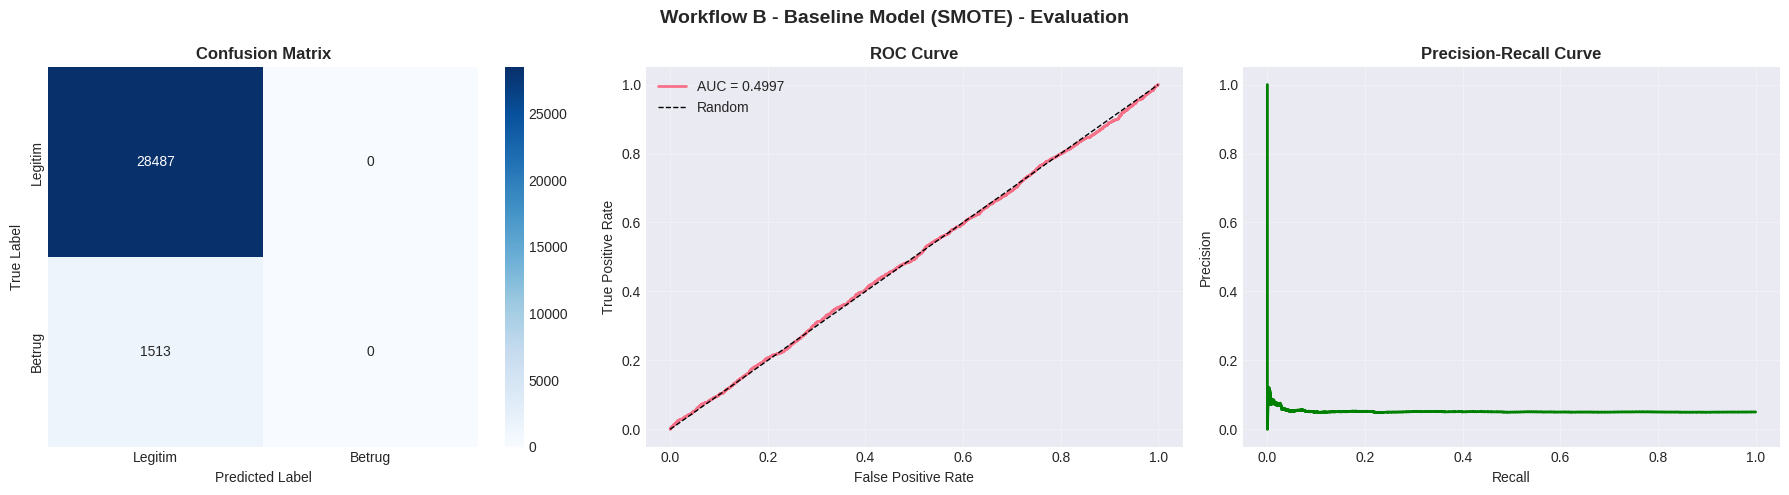


Zusätzliche Metriken:
True Negatives: 28487
False Positives: 0
False Negatives: 1513
True Positives: 0
Specificity (True Negative Rate): 1.0000
Sensitivity (True Positive Rate/Recall): 0.0000


In [28]:
# Baseline SMOTE Model evaluieren
baseline_smote_results = evaluate_model(baseline_smote, X_test_scaled, y_test, "Workflow B - Baseline Model (SMOTE)")

### 4.3 Hyperparameter-Tuning MIT SMOTE

In [29]:
# Keras Tuner für SMOTE Workflow
print("=" * 80)
print("WORKFLOW B: Hyperparameter-Tuning (SMOTE)")
print("=" * 80)
print()

tuner_smote = kt.BayesianOptimization(
    build_tuner_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=20,
    executions_per_trial=1,
    directory='tuner_results_smote',
    project_name='fraud_detection_smote',
    overwrite=True
)

tuner_smote.search(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max')
    ],
    verbose=0
)

print("\nHyperparameter-Suche abgeschlossen (Workflow B)")

WORKFLOW B: Hyperparameter-Tuning (SMOTE)


Hyperparameter-Suche abgeschlossen (Workflow B)


In [30]:
# Beste Hyperparameter abrufen (Workflow B)
best_hps_smote = tuner_smote.get_best_hyperparameters(num_trials=1)[0]

print("=" * 80)
print("BESTE HYPERPARAMETER (WORKFLOW B - SMOTE)")
print("=" * 80)
print(f"Units Layer 1: {best_hps_smote.get('units_1')}")
print(f"Units Layer 2: {best_hps_smote.get('units_2')}")
print(f"Units Layer 3: {best_hps_smote.get('units_3')}")
print(f"Learning Rate: {best_hps_smote.get('learning_rate'):.6f}")
print("=" * 80)

BESTE HYPERPARAMETER (WORKFLOW B - SMOTE)
Units Layer 1: 32
Units Layer 2: 32
Units Layer 3: 32
Learning Rate: 0.000100


In [31]:
# Bestes Modell mit optimalen Hyperparametern trainieren (Workflow B)
best_smote = tuner_smote.hypermodel.build(best_hps_smote)

print("Training des besten Modells (Workflow B - SMOTE)...")

history_best_smote = best_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
        callbacks.ModelCheckpoint('best_model_smote.h5', monitor='val_auc', save_best_only=True, mode='max')
    ],
    verbose=1
)

print("\nTraining abgeschlossen (Workflow B - Best Model)")

Training des besten Modells (Workflow B - SMOTE)...
Epoch 1/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6499 - auc: 0.5181 - loss: 0.6502 - precision: 0.3263 - recall: 0.0482  

779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6618 - auc: 0.5250 - loss: 0.6426 - precision: 0.3261 - recall: 0.0136 - val_accuracy: 0.9496 - val_auc: 0.5066 - val_loss: 0.5229 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/100
704/779 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.6656 - auc: 0.5320 - loss: 0.6380 - precision: 0.0149 - recall: 1.5579e-06    

779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.6666 - auc: 0.5354 - loss: 0.6365 - precision: 0.1667 - recall: 1.5045e-05 - val_accuracy: 0.9496 - val_auc: 0.5066 - val_loss: 0.5183 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 701us/step - accuracy: 0.6667 - auc: 0.5460 - loss: 0.6340 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9496 - val_auc: 0.5037 - val_loss: 0.5236 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.6667 - auc: 0.5499 - loss: 0.6333 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9496 - val_auc: 0.5043 - val_loss: 0.5256 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - accuracy: 0.6667 - auc: 0.5576 - loss: 0.6319 - precision: 0.0000e+00 - recall: 0.0000e+00 -

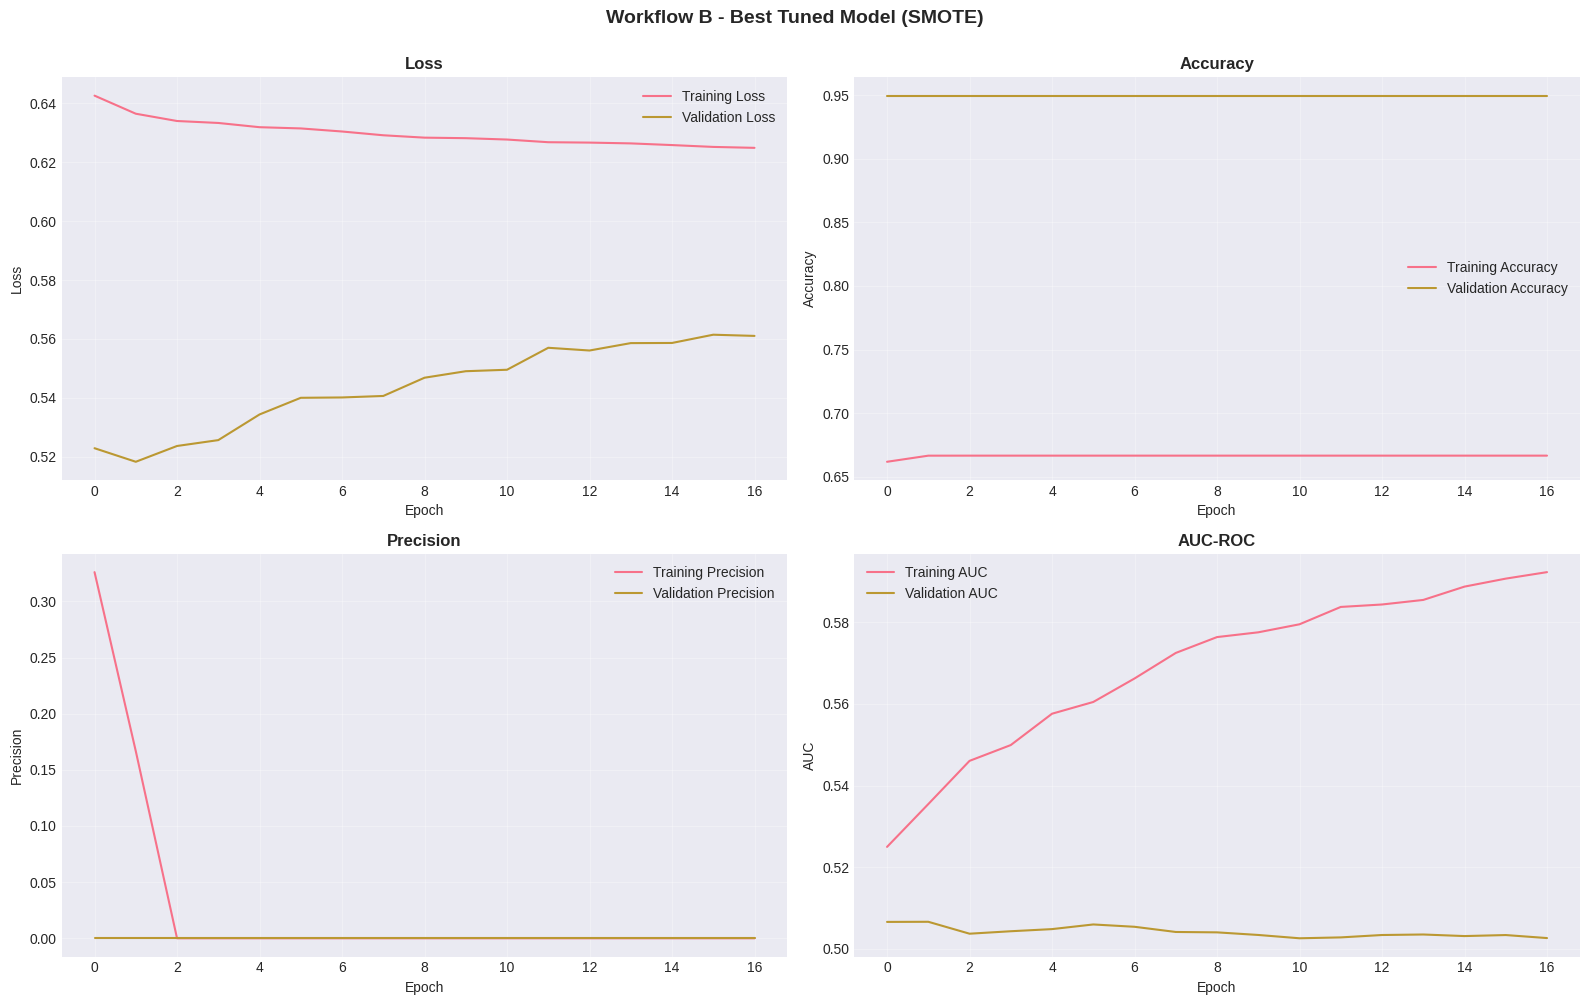

In [32]:
# Training History visualisieren (Workflow B - Best Model)
plot_training_history(history_best_smote, "Workflow B - Best Tuned Model (SMOTE)")

EVALUATION: Workflow B - Best Tuned Model (SMOTE)

Classification Report:
              precision    recall  f1-score   support

     Legitim       0.95      1.00      0.97     28487
      Betrug       0.00      0.00      0.00      1513

    accuracy                           0.95     30000
   macro avg       0.47      0.50      0.49     30000
weighted avg       0.90      0.95      0.93     30000

AUC-ROC Score: 0.4908


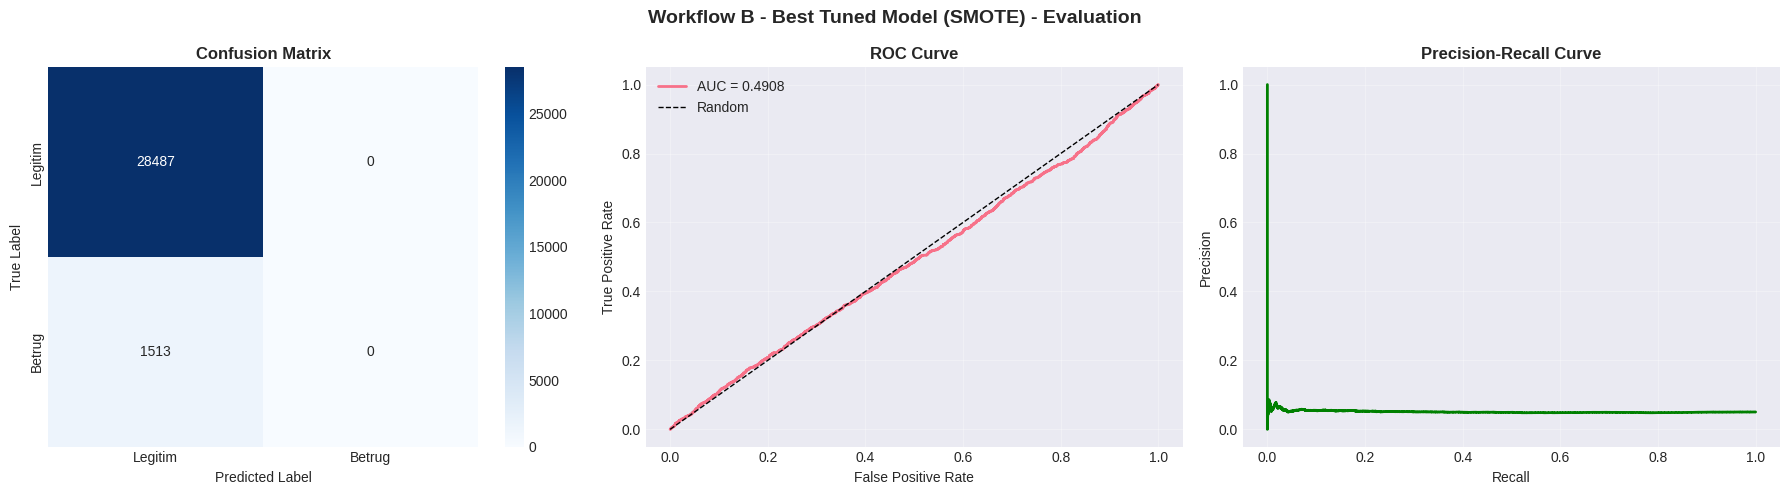


Zusätzliche Metriken:
True Negatives: 28487
False Positives: 0
False Negatives: 1513
True Positives: 0
Specificity (True Negative Rate): 1.0000
Sensitivity (True Positive Rate/Recall): 0.0000


In [33]:
# Best SMOTE Model evaluieren
best_smote_results = evaluate_model(best_smote, X_test_scaled, y_test, "Workflow B - Best Tuned Model (SMOTE)")

### 4.4 Alternative Architektur: Deep Network (SMOTE)

In [34]:
# Deep Model für SMOTE Workflow
deep_smote = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')
])

deep_smote.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), 
             keras.metrics.Precision(name='precision'), 
             keras.metrics.Recall(name='recall')]
)

print("Deep Model (SMOTE) Architektur:")
deep_smote.summary()

Deep Model (SMOTE) Architektur:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,433 (197.00 KB)

 Trainable params: 49,537 (193.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [35]:
# Deep Model trainieren (Workflow B: SMOTE)
print("=" * 80)
print("WORKFLOW B: Training Deep Model (SMOTE)")
print("=" * 80)
print()

history_deep_smote = deep_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
        callbacks.ModelCheckpoint('deep_model_smote.h5', monitor='val_auc', save_best_only=True, mode='max')
    ],
    verbose=1
)

print("\nTraining abgeschlossen (Workflow B - Deep Model)")

WORKFLOW B: Training Deep Model (SMOTE)

Epoch 1/100


779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5353 - auc: 0.5080 - loss: 1.1140 - precision: 0.3357 - recall: 0.3962

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5736 - auc: 0.5203 - loss: 1.0560 - precision: 0.3416 - recall: 0.3010 - val_accuracy: 0.9233 - val_auc: 0.4974 - val_loss: 0.7777 - val_precision: 0.0375 - val_recall: 0.0212 - learning_rate: 1.0000e-04
Epoch 2/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6260 - auc: 0.5521 - loss: 0.9663 - precision: 0.3781 - recall: 0.1895 - val_accuracy: 0.9208 - val_auc: 0.4960 - val_loss: 0.7799 - val_precision: 0.0463 - val_recall: 0.0291 - learning_rate: 1.0000e-04
Epoch 3/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6419 - auc: 0.5689 - loss: 0.9231 - precision: 0.4034 - recall: 0.1551 - val_accuracy: 0.9170 - val_auc: 0.4968 - val_loss: 0.7690 - val_precision: 0.0595 - val_recall: 0.0436 - learning_rate: 1.0000e-04
Epoch 4/100
731/779 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6485 - auc: 0.5840 - loss: 0.8951 - precision: 0.4205 - recall: 0.1369

779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6525 - auc: 0.5883 - loss: 0.8854 - precision: 0.4317 - recall: 0.1348 - val_accuracy: 0.9057 - val_auc: 0.5000 - val_loss: 0.7511 - val_precision: 0.0602 - val_recall: 0.0595 - learning_rate: 1.0000e-04
Epoch 5/100
735/779 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6593 - auc: 0.5993 - loss: 0.8598 - precision: 0.4505 - recall: 0.1206

779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6590 - auc: 0.6038 - loss: 0.8525 - precision: 0.4569 - recall: 0.1213 - val_accuracy: 0.8916 - val_auc: 0.5015 - val_loss: 0.7367 - val_precision: 0.0548 - val_recall: 0.0707 - learning_rate: 1.0000e-04
Epoch 6/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6654 - auc: 0.6186 - loss: 0.8218 - precision: 0.4927 - recall: 0.1238 - val_accuracy: 0.8911 - val_auc: 0.5010 - val_loss: 0.7091 - val_precision: 0.0557 - val_recall: 0.0727 - learning_rate: 1.0000e-04
Epoch 7/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6688 - auc: 0.6326 - loss: 0.7931 - precision: 0.5129 - recall: 0.1262 - val_accuracy: 0.8769 - val_auc: 0.4985 - val_loss: 0.6851 - val_precision: 0.0525 - val_recall: 0.0846 - learning_rate: 1.0000e-04
Epoch 8/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6707 - auc: 0.6417 - loss: 0.7680 - precision: 0.5234 - recall: 0.1354 - val_accuracy: 0.8655 - val_auc: 0.4988 - val_loss: 0.6641 -

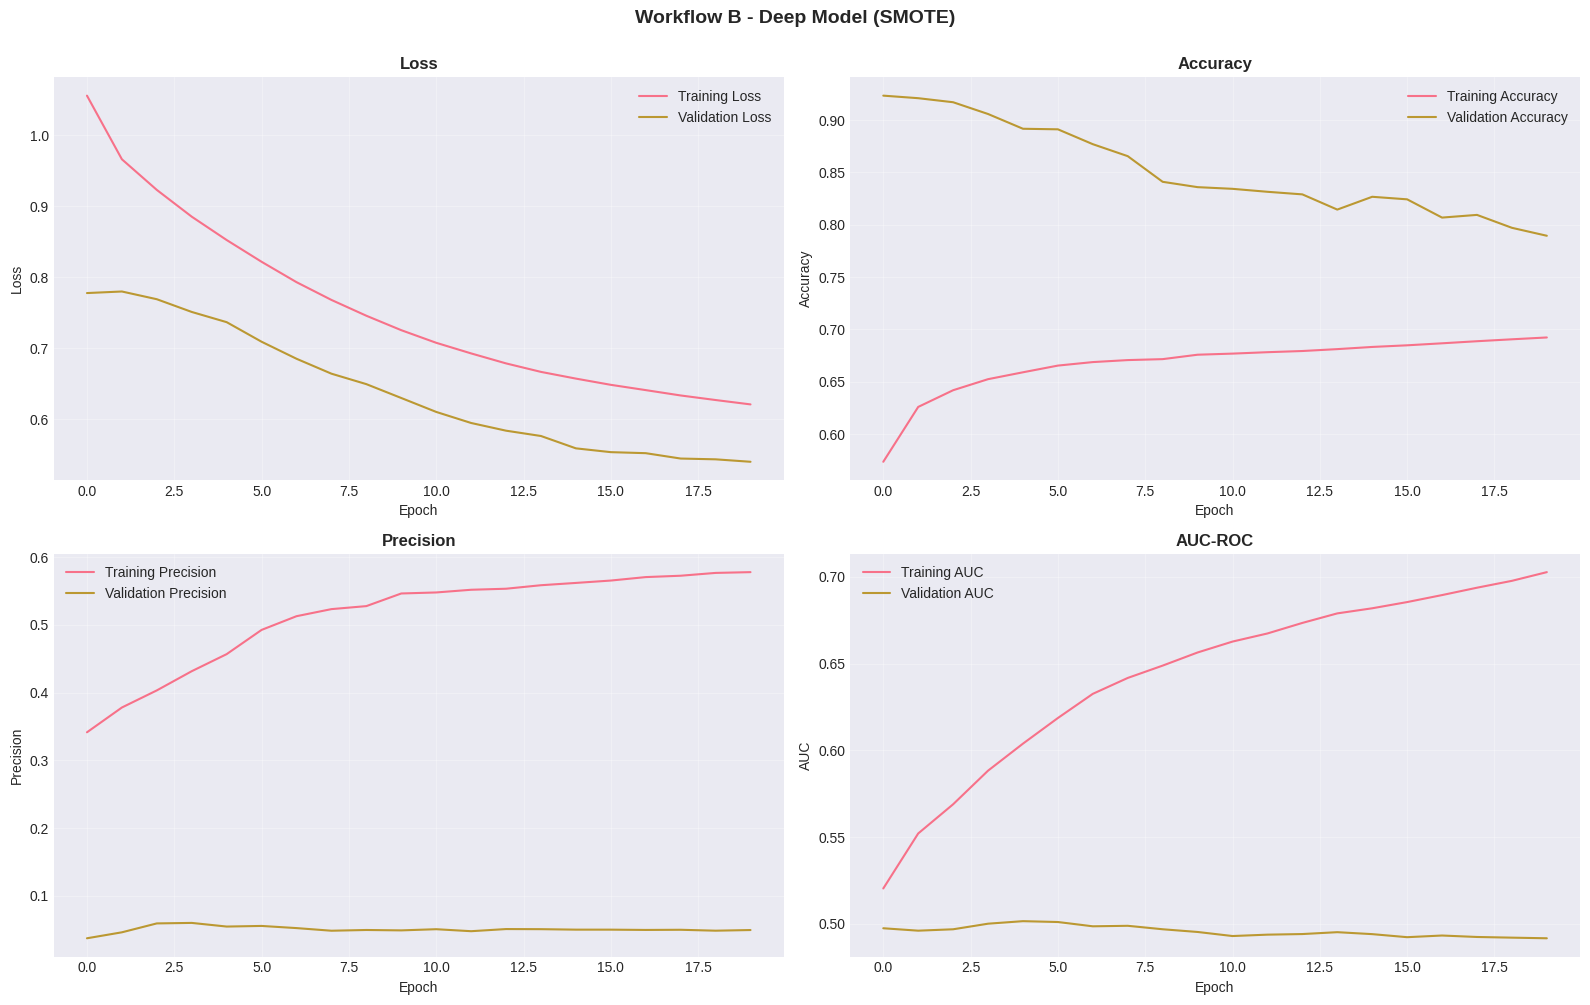

In [36]:
# Training History visualisieren (Workflow B - Deep Model)
plot_training_history(history_deep_smote, "Workflow B - Deep Model (SMOTE)")

EVALUATION: Workflow B - Deep Model (SMOTE)

Classification Report:
              precision    recall  f1-score   support

     Legitim       0.95      0.93      0.94     28487
      Betrug       0.05      0.07      0.06      1513

    accuracy                           0.89     30000
   macro avg       0.50      0.50      0.50     30000
weighted avg       0.90      0.89      0.90     30000

AUC-ROC Score: 0.4992


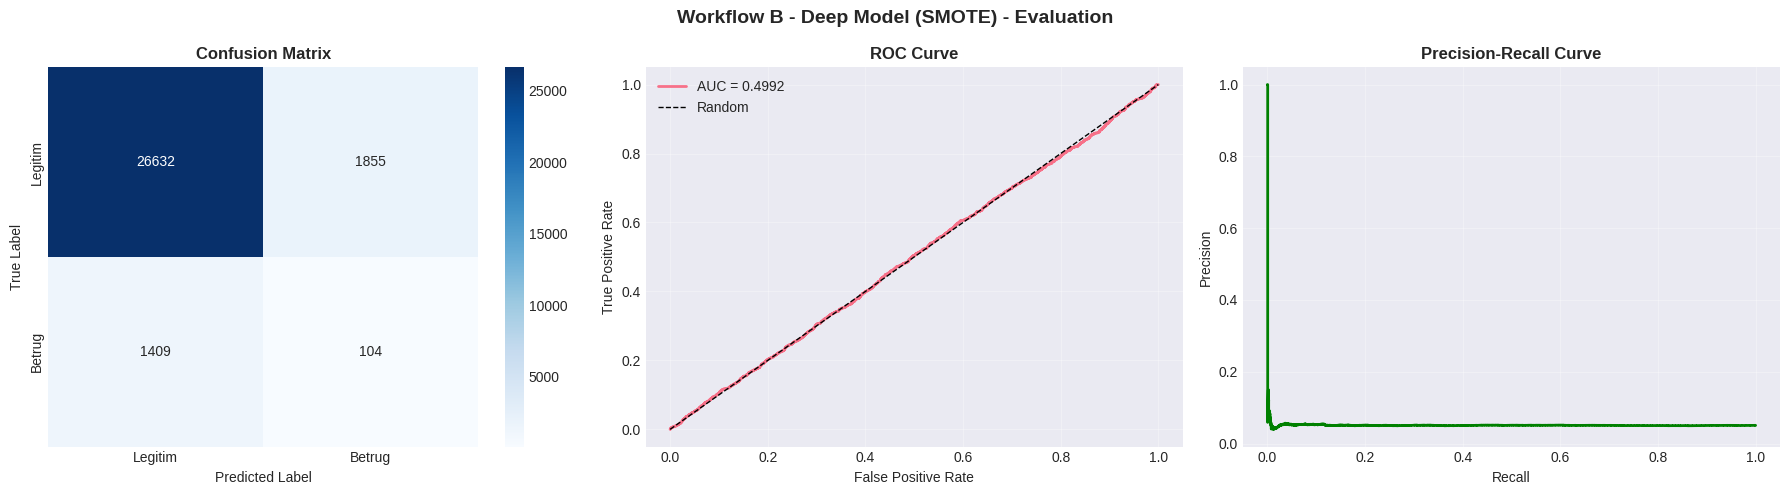


Zusätzliche Metriken:
True Negatives: 26632
False Positives: 1855
False Negatives: 1409
True Positives: 104
Specificity (True Negative Rate): 0.9349
Sensitivity (True Positive Rate/Recall): 0.0687


In [37]:
# Deep SMOTE Model evaluieren
deep_smote_results = evaluate_model(deep_smote, X_test_scaled, y_test, "Workflow B - Deep Model (SMOTE)")

## 5. VERGLEICH: Workflow A vs. Workflow B

In [38]:
# Alle Modelle vergleichen
print("=" * 80)
print("VOLLSTÄNDIGER MODELLVERGLEICH")
print("=" * 80)
print()

models_comparison = {
    'A-Baseline (Class Weights)': baseline_cw_results,
    'A-Best Tuned (Class Weights)': best_model_cw_results,
    'A-Deep (Class Weights)': deep_cw_results,
    'B-Baseline (SMOTE)': baseline_smote_results,
    'B-Best Tuned (SMOTE)': best_smote_results,
    'B-Deep (SMOTE)': deep_smote_results
}

comparison_df = pd.DataFrame()

for model_name, results in models_comparison.items():
    cm = results['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    comparison_df[model_name] = {
        'AUC-ROC': results['auc'],
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Specificity': specificity,
        'True Positives': tp,
        'False Positives': fp,
        'False Negatives': fn,
        'True Negatives': tn
    }

comparison_df = comparison_df.T
print(comparison_df)

# Als CSV speichern
comparison_df.to_csv('model_comparison_complete.csv')
print("\nVergleich als CSV gespeichert")

VOLLSTÄNDIGER MODELLVERGLEICH

                               AUC-ROC  Precision    Recall  F1-Score  \
A-Baseline (Class Weights)    0.501296   0.051498  0.384005  0.090817   
A-Best Tuned (Class Weights)  0.495207   0.049484  0.503635  0.090114   
A-Deep (Class Weights)        0.495135   0.049097  0.499670  0.089409   
B-Baseline (SMOTE)            0.499747   0.000000  0.000000  0.000000   
B-Best Tuned (SMOTE)          0.490784   0.000000  0.000000  0.000000   
B-Deep (SMOTE)                0.499222   0.053088  0.068738  0.059908   

                              Specificity  True Positives  False Positives  \
A-Baseline (Class Weights)       0.624355           581.0          10701.0   
A-Best Tuned (Class Weights)     0.486187           762.0          14637.0   
A-Deep (Class Weights)           0.486011           756.0          14642.0   
B-Baseline (SMOTE)               1.000000             0.0              0.0   
B-Best Tuned (SMOTE)             1.000000             0.0          

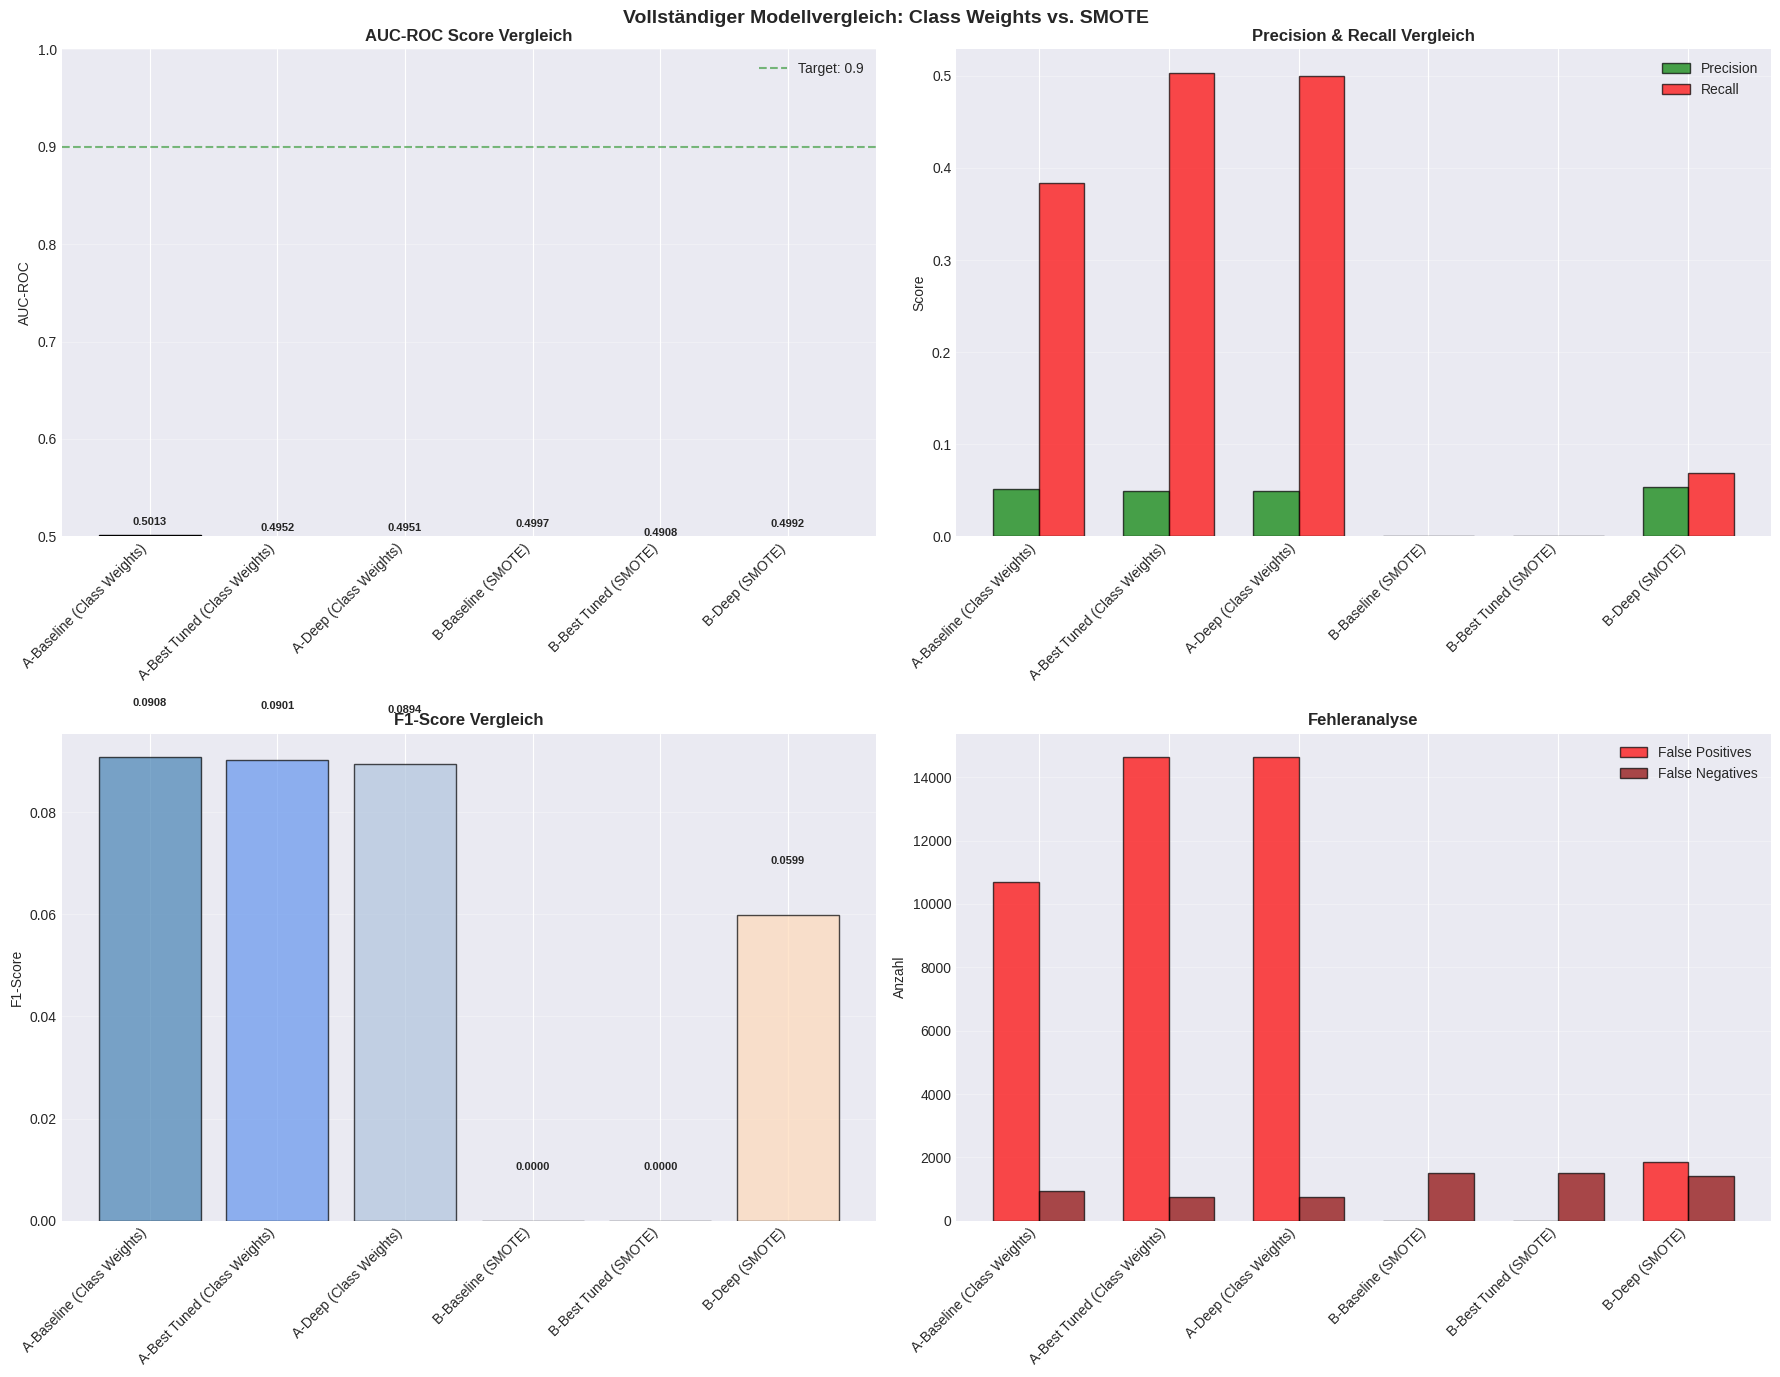

Vergleichsvisualisierung erstellt


In [39]:
# Visualisierung des Modellvergleichs
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Farben für die beiden Workflows
colors = ['steelblue', 'cornflowerblue', 'lightsteelblue', 'darkorange', 'orange', 'peachpuff']

# AUC-ROC Vergleich
axes[0, 0].bar(range(len(comparison_df.index)), comparison_df['AUC-ROC'], color=colors, edgecolor='black')
axes[0, 0].set_title('AUC-ROC Score Vergleich', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('AUC-ROC')
axes[0, 0].set_ylim([0.5, 1.0])
axes[0, 0].set_xticks(range(len(comparison_df.index)))
axes[0, 0].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[0, 0].grid(alpha=0.3, axis='y')
axes[0, 0].axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Target: 0.9')
axes[0, 0].legend()
for i, v in enumerate(comparison_df['AUC-ROC']):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=8)

# Precision & Recall
x = np.arange(len(comparison_df.index))
width = 0.35
axes[0, 1].bar(x - width/2, comparison_df['Precision'], width, label='Precision', color='green', alpha=0.7, edgecolor='black')
axes[0, 1].bar(x + width/2, comparison_df['Recall'], width, label='Recall', color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Precision & Recall Vergleich', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

# F1-Score
axes[1, 0].bar(range(len(comparison_df.index)), comparison_df['F1-Score'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('F1-Score Vergleich', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_xticks(range(len(comparison_df.index)))
axes[1, 0].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[1, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['F1-Score']):
    axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=8)

# False Positives & False Negatives
axes[1, 1].bar(x - width/2, comparison_df['False Positives'], width, label='False Positives', color='red', alpha=0.7, edgecolor='black')
axes[1, 1].bar(x + width/2, comparison_df['False Negatives'], width, label='False Negatives', color='darkred', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Fehleranalyse', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Anzahl')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_df.index, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Vollständiger Modellvergleich: Class Weights vs. SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_complete.png', dpi=300, bbox_inches='tight')
plt.show()

print("Vergleichsvisualisierung erstellt")

## 6. Workflow-Vergleich: Welcher Ansatz ist besser?

In [40]:
# Aggregierter Vergleich: Class Weights vs. SMOTE
print("=" * 80)
print("WORKFLOW-VERGLEICH: CLASS WEIGHTS vs. SMOTE")
print("=" * 80)
print()

workflow_a_models = ['A-Baseline (Class Weights)', 'A-Best Tuned (Class Weights)', 'A-Deep (Class Weights)']
workflow_b_models = ['B-Baseline (SMOTE)', 'B-Best Tuned (SMOTE)', 'B-Deep (SMOTE)']

workflow_comparison = pd.DataFrame({
    'Workflow A (Class Weights)': comparison_df.loc[workflow_a_models, ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']].mean(),
    'Workflow B (SMOTE)': comparison_df.loc[workflow_b_models, ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']].mean()
})

print("Durchschnittliche Performance:")
print(workflow_comparison)
print()

# Beste Modelle aus jedem Workflow
best_a = comparison_df.loc[workflow_a_models, 'AUC-ROC'].idxmax()
best_b = comparison_df.loc[workflow_b_models, 'AUC-ROC'].idxmax()

print(f"Bestes Modell Workflow A: {best_a}")
print(f"  AUC-ROC: {comparison_df.loc[best_a, 'AUC-ROC']:.4f}")
print(f"  F1-Score: {comparison_df.loc[best_a, 'F1-Score']:.4f}")
print()
print(f"Bestes Modell Workflow B: {best_b}")
print(f"  AUC-ROC: {comparison_df.loc[best_b, 'AUC-ROC']:.4f}")
print(f"  F1-Score: {comparison_df.loc[best_b, 'F1-Score']:.4f}")

WORKFLOW-VERGLEICH: CLASS WEIGHTS vs. SMOTE

Durchschnittliche Performance:
           Workflow A (Class Weights)  Workflow B (SMOTE)
AUC-ROC                      0.497213            0.496584
Precision                    0.050026            0.017696
Recall                       0.462437            0.022913
F1-Score                     0.090113            0.019969

Bestes Modell Workflow A: A-Baseline (Class Weights)
  AUC-ROC: 0.5013
  F1-Score: 0.0908

Bestes Modell Workflow B: B-Baseline (SMOTE)
  AUC-ROC: 0.4997
  F1-Score: 0.0000


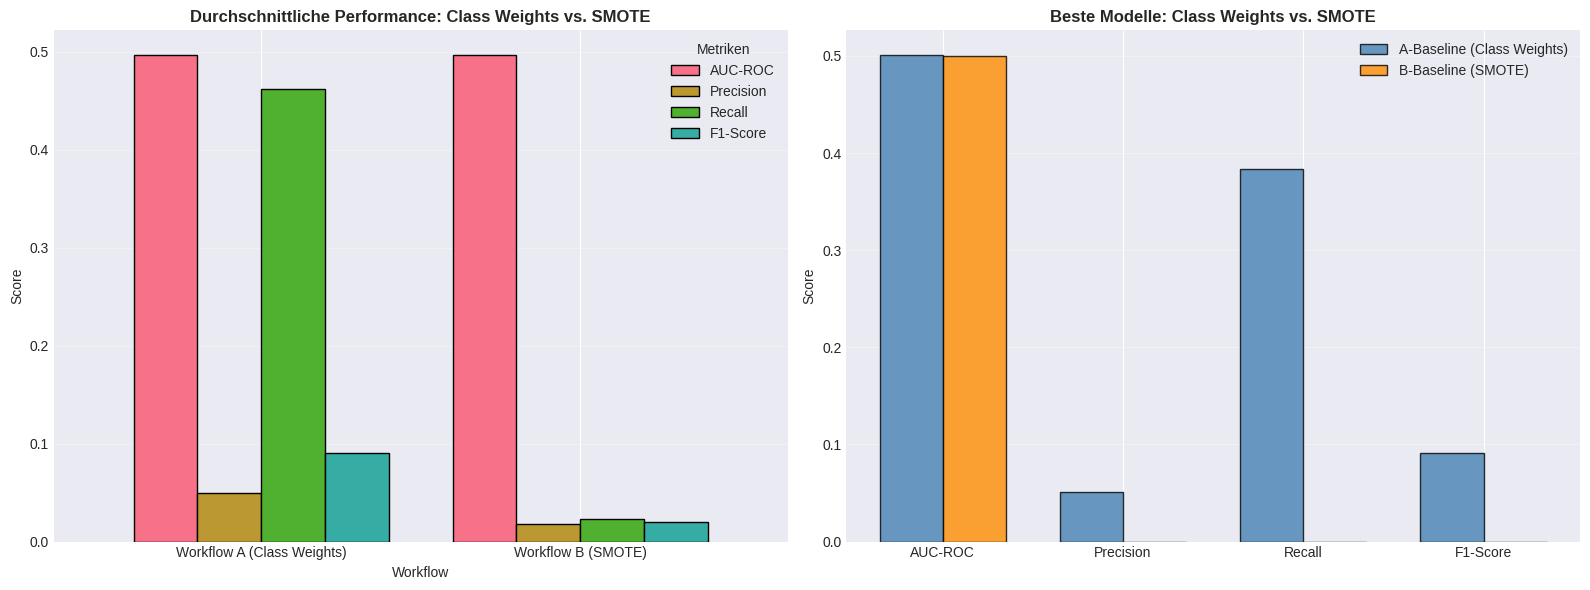

Workflow-Vergleich visualisiert


In [41]:
# Visualisierung: Workflow-Vergleich
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Durchschnittliche Metriken
workflow_comparison.T.plot(kind='bar', ax=axes[0], rot=0, width=0.8, edgecolor='black')
axes[0].set_title('Durchschnittliche Performance: Class Weights vs. SMOTE', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Workflow')
axes[0].legend(title='Metriken')
axes[0].grid(alpha=0.3, axis='y')

# Beste Modelle aus jedem Workflow
best_models_data = comparison_df.loc[[best_a, best_b], ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']]
x = np.arange(len(best_models_data.columns))
width = 0.35

axes[1].bar(x - width/2, best_models_data.iloc[0], width, label=best_a, color='steelblue', alpha=0.8, edgecolor='black')
axes[1].bar(x + width/2, best_models_data.iloc[1], width, label=best_b, color='darkorange', alpha=0.8, edgecolor='black')
axes[1].set_title('Beste Modelle: Class Weights vs. SMOTE', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(best_models_data.columns)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('workflow_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Workflow-Vergleich visualisiert")

### Warum Ergebnisse suboptimal?

Meine mögliche Ursache die ggf. die schlechten Ergebnisse zur Folge haben könnten:
- Aktuelle Feature-Menge scheint geringe Trennschärfe zu besitzen (niedriger Recall bei allen Architekturen). Vermutlich fehlen kunden-/zeitbezogene aggregierte Merkmale was wir auch schon mal besprochen hatten 
   --> z.B. Transaktionsfrequenz letzte 1h/24h/7d, durchschnittliche Beträge, Abweichungen, Ratio Feature A/B, Flag für ungewöhnliche Uhrzeiten, etc.

## 7. Erklärbare KI: Modellinterpretation

Grundlage ist das optimierte Class-Weights-Modell (`best_tuned_model_cw.h5`)


### 7.1 Vorbereitung & Auswahl der True Positives

Nur die Betrugsfälle, die vom Modell korrekt erkannt wurden --> So vermeiden wir, dass Fehlklassifikationen die Interpretation verfälschen.


In [6]:
# Bestes Modell laden und korrekt klassifizierte Betrugsfälle isolieren
best_model_path = 'best_tuned_model_cw.h5'
best_model_loaded = keras.models.load_model(best_model_path)

y_test_proba_best = best_model_loaded.predict(X_test_scaled, verbose=0).flatten()
y_test_pred_best = (y_test_proba_best > 0.5).astype(int)

true_fraud_mask = (y_test.values == 1)
correct_fraud_mask = true_fraud_mask & (y_test_pred_best == 1)
n_true_fraud = int(true_fraud_mask.sum())
n_correct_fraud = int(correct_fraud_mask.sum())

print(f'Betrugsfälle im Testset: {n_true_fraud}')
print(f'Korrekt erkannte Betrugsfälle (True Positives): {n_correct_fraud}')

if n_correct_fraud == 0:
    raise ValueError('Keine korrekt erkannten Betrugsfälle vorhanden – SHAP-Analyse nicht möglich.')

correct_fraud_scaled = X_test_scaled[correct_fraud_mask]
correct_fraud_df = X_test.iloc[correct_fraud_mask].reset_index(drop=True)
y_correct_fraud_proba = y_test_proba_best[correct_fraud_mask]

print(f'SHAP-Analyse basiert auf {correct_fraud_scaled.shape[0]} True-Positive Fällen.')


2025-11-13 16:41:38.565942: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fca4c007370 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 16:41:38.565956: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 16:41:38.568727: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763048498.589317 2267937 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Betrugsfälle im Testset: 1513
Korrekt erkannte Betrugsfälle (True Positives): 762
SHAP-Analyse basiert auf 762 True-Positive Fällen.


### 7.2 Globale SHAP-Analyse

SHAP (SHapley Additive exPlanations) zeigt, wie stark einzelne Merkmale den Klassifikationsausgang auf "Betrug" verschieben.
Als Referenz dient eine Stichprobe aus den Trainingsdaten; analysiert werden ausschließlich True Positives, um ein realistisches Bild der Modelllogik zu erhalten.


In [7]:
# SHAP-Explainer vorbereiten und Werte berechnen
rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
background_sample = X_train_scaled[background_idx]

explainer = shap.DeepExplainer(best_model_loaded, background_sample)
shap_values_tp_raw = explainer.shap_values(correct_fraud_scaled)

if isinstance(shap_values_tp_raw, list):
    shap_values_tp_raw = shap_values_tp_raw[0]

shap_values_tp = np.array(shap_values_tp_raw)
if shap_values_tp.ndim == 3 and shap_values_tp.shape[-1] == 1:
    shap_values_tp = np.squeeze(shap_values_tp, axis=-1)

expected_value_tp = explainer.expected_value
if isinstance(expected_value_tp, (list, tuple, np.ndarray)):
    expected_value_tp = np.array(expected_value_tp).reshape(-1)[0]

shap_base_values = np.repeat(expected_value_tp, correct_fraud_scaled.shape[0])
shap_explanation_tp = shap.Explanation(
    values=shap_values_tp,
    base_values=shap_base_values,
    data=correct_fraud_df.values,
    feature_names=list(correct_fraud_df.columns)
)

print('SHAP-Werte erfolgreich berechnet.')


SHAP-Werte erfolgreich berechnet.


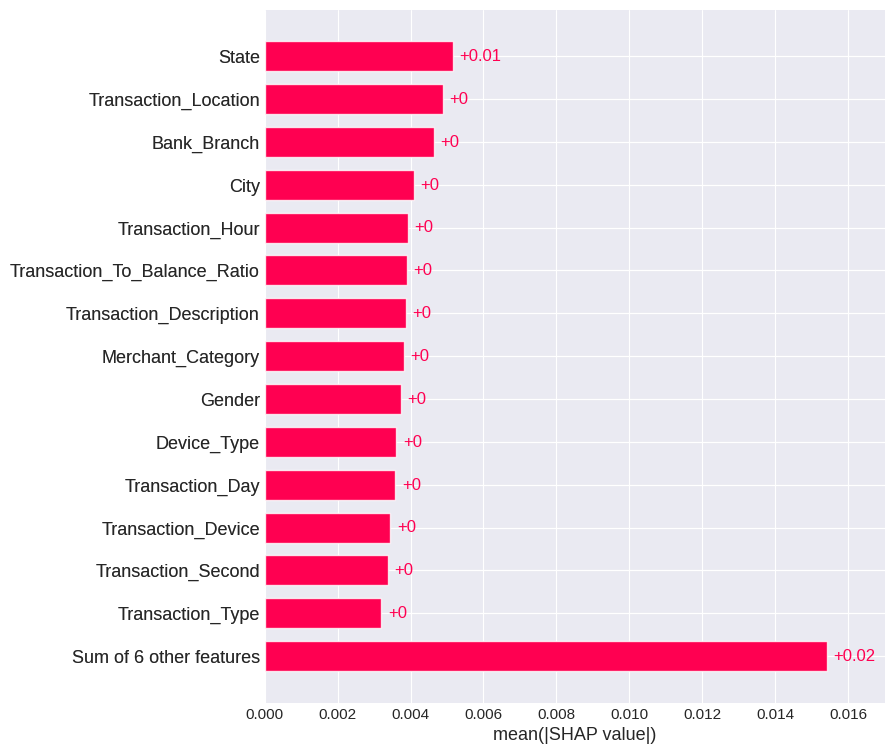

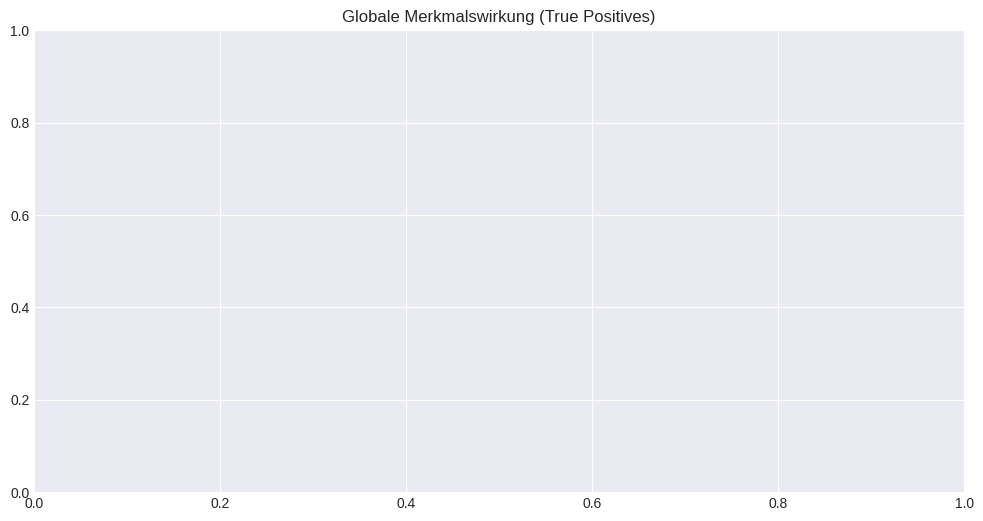

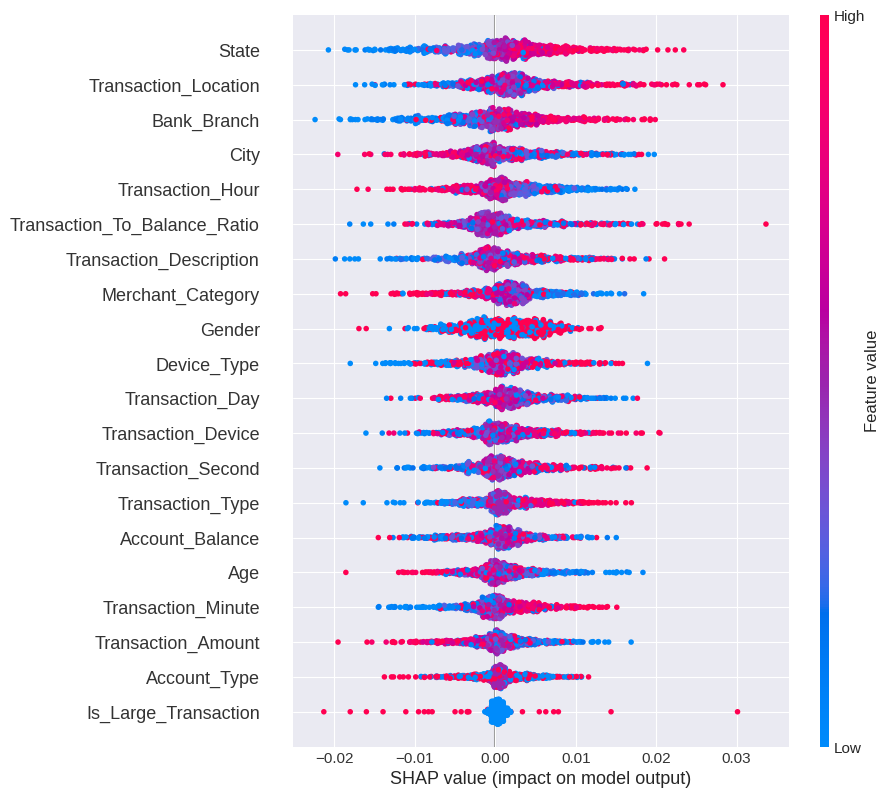

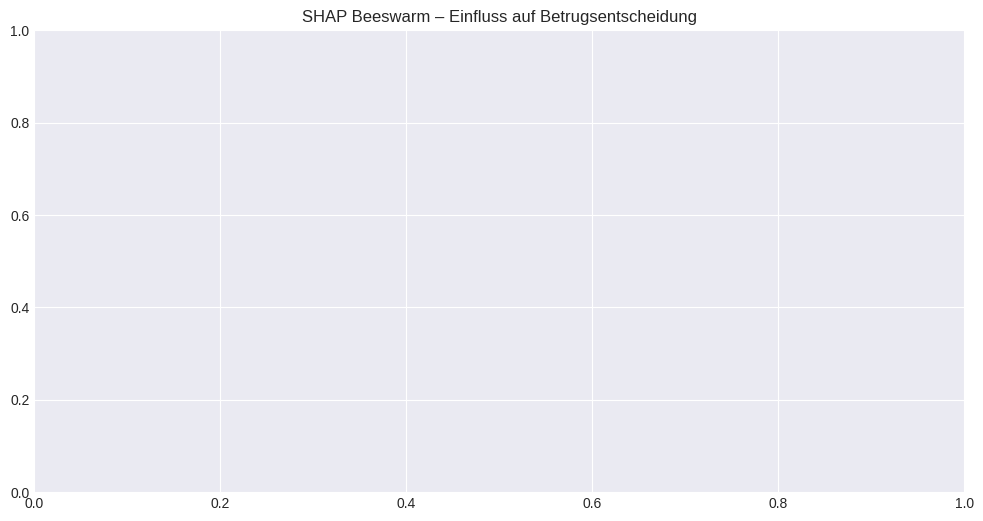

In [8]:
# Globale SHAP-Visualisierungen
shap.plots.bar(shap_explanation_tp, max_display=15)
plt.title('Globale Merkmalswirkung (True Positives)')
plt.show()

shap.plots.beeswarm(shap_explanation_tp, max_display=20)
plt.title('SHAP Beeswarm – Einfluss auf Betrugsentscheidung')
plt.show()


**Interpretation der SHAP-Visualisierungen:**
- **State** (Bundesstaat), **Transaction_Location** (Transaktionsort) und **Bank_Branch** (Bankfiliale) zeigen den stärksten Einfluss auf die Betrugserkennung - geografische Faktoren sind entscheidend für die Identifikation verdächtiger Transaktionen
- **Transaction_Hour** (Uhrzeit), **Transaction_To_Balance_Ratio** (Verhältnis Transaktion zu Kontostand) und **Merchant_Category** (Händlerkategorie) sind weitere wichtige Indikatoren, die auf ungewöhnliche Transaktionsmuster hinweisen

In [9]:
# Mittlere absolute SHAP-Werte tabellarisch darstellen
mean_abs_shap = np.abs(shap_explanation_tp.values).mean(axis=0)
feature_importance_tp = (
    pd.DataFrame({
        'Feature': shap_explanation_tp.feature_names,
        'Mittlere |SHAP|-Wirkung': mean_abs_shap,
    })
    .sort_values('Mittlere |SHAP|-Wirkung', ascending=False)
)
feature_importance_tp.reset_index(drop=True, inplace=True)
feature_importance_tp.head(15)


,Feature,Mittlere |SHAP|-Wirkung
0,State,0.005159
1,Transaction_Location,0.004879
2,Bank_Branch,0.004646
3,City,0.004094
4,Transaction_Hour,0.003930
5,Transaction_To_Balance_Ratio,0.003894
6,Transaction_Description,0.003877
7,Merchant_Category,0.003811
8,Gender,0.003742
9,Device_Type,0.003612


### 7.3 Lokale Fallanalyse

Für die Berichtserstellung betrachten wir exemplarisch den True-Positive Fall mit der höchsten Betrugswahrscheinlichkeit und analysieren dessen Merkmalsbeiträge.


Ausgewählter Fall: Index 698 innerhalb der True-Positive Menge | Modell-P(Betrug) = 0.5849


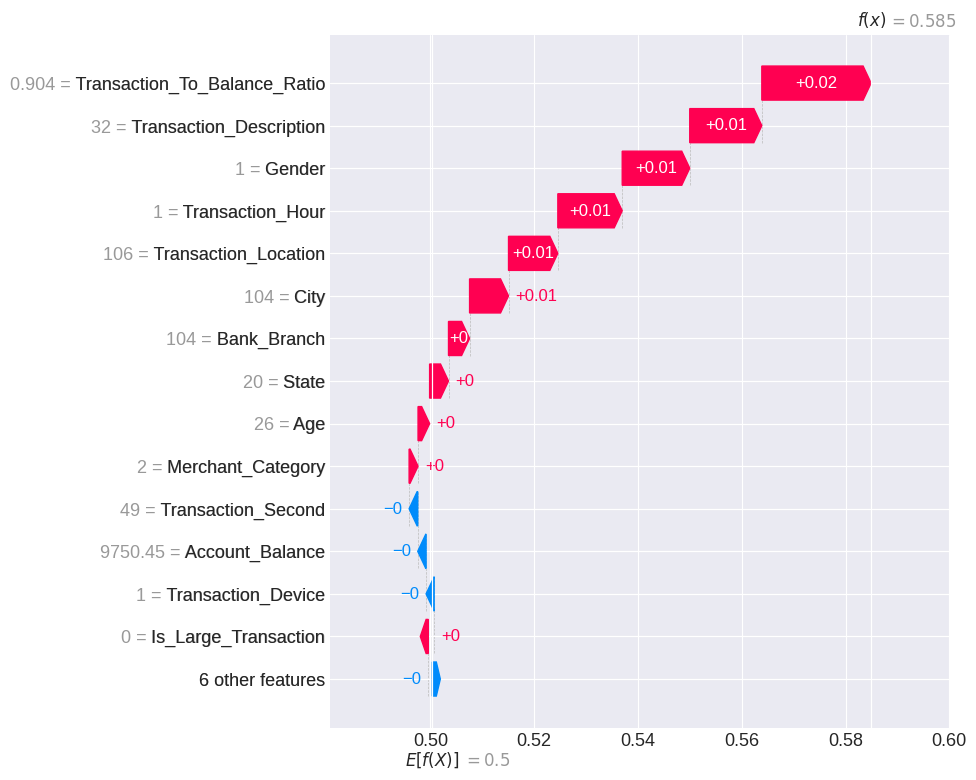

In [11]:
# Lokale Erklärung für den Betrugsfall mit höchster Modellwahrscheinlichkeit
top_case_idx = int(np.argmax(y_correct_fraud_proba))
print(f'Ausgewählter Fall: Index {top_case_idx} innerhalb der True-Positive Menge | Modell-P(Betrug) = {y_correct_fraud_proba[top_case_idx]:.4f}')

shap.plots.waterfall(shap_explanation_tp[top_case_idx], max_display=15)


**Interpretation des SHAP Waterfall-Diagramms:**
- Für diesen konkreten Betrugsfall mit höchster Erkennungswahrscheinlichkeit zeigt sich, welche spezifischen Merkmalskombinationen zur Betrugsklassifikation führten
- Rote Balken (nach rechts) identifizieren verdächtige Merkmale wie ungewöhnliche Transaktionsorte, auffällige Transaktionszeiten oder abweichende Merchant-Kategorien, die das Modell als Betrugsindikator wertet
- Blaue Balken (nach links) repräsentieren Merkmale, die den Fall eher als legitim erscheinen lassen, aber durch die Gesamtkombination verdächtiger Faktoren überstimmt werden

### 7.4 Permutationsbasierte Merkmalswirkung

Zur Ergänzung von SHAP analysieren wir, wie stark die mittlere Betrugswahrscheinlichkeit sinkt, wenn einzelne Features zufällig permutiert werden.
Damit betrachten wir ausschließlich True Positives und messen die Stabilität der Entscheidung des Modells.

In [12]:
# Permutationsbasierte Sensitivität für korrekt erkannte Betrugsfälle
rng_perm = np.random.default_rng(42)
n_repeats = 8
baseline_mean_prob = y_correct_fraud_proba.mean()
feature_names = np.array(correct_fraud_df.columns)
permutation_records = []

for feature_idx, feature_name in enumerate(feature_names):
    drops = []
    for _ in range(n_repeats):
        permuted = correct_fraud_scaled.copy()
        permuted[:, feature_idx] = rng_perm.permutation(permuted[:, feature_idx])
        permuted_proba = best_model_loaded.predict(permuted, verbose=0).flatten()
        drops.append(baseline_mean_prob - permuted_proba.mean())
    permutation_records.append({
        'Feature': feature_name,
        'Mittlerer Drop in P(Betrug)': np.mean(drops),
        'Std Drop': np.std(drops)
    })

permutation_importance_tp = (
    pd.DataFrame(permutation_records)
    .sort_values('Mittlerer Drop in P(Betrug)', ascending=False)
    .reset_index(drop=True)
)

print(f'Baseline mittlere Betrugswahrscheinlichkeit (True Positives): {baseline_mean_prob:.4f}')
permutation_importance_tp.head(15)

Baseline mittlere Betrugswahrscheinlichkeit (True Positives): 0.5198


,Feature,Mittlerer Drop in P(Betrug),Std Drop
0,City,0.004153,0.000386
1,Transaction_Day,0.003424,0.000259
2,Account_Balance,0.003295,0.000327
3,Gender,0.003249,0.000252
4,Transaction_To_Balance_Ratio,0.003182,0.000307
5,Transaction_Device,0.003013,0.000399
6,Transaction_Type,0.002766,0.000240
7,Device_Type,0.002742,0.000307
8,Age,0.002691,0.000257
9,Transaction_Description,0.002688,0.000293


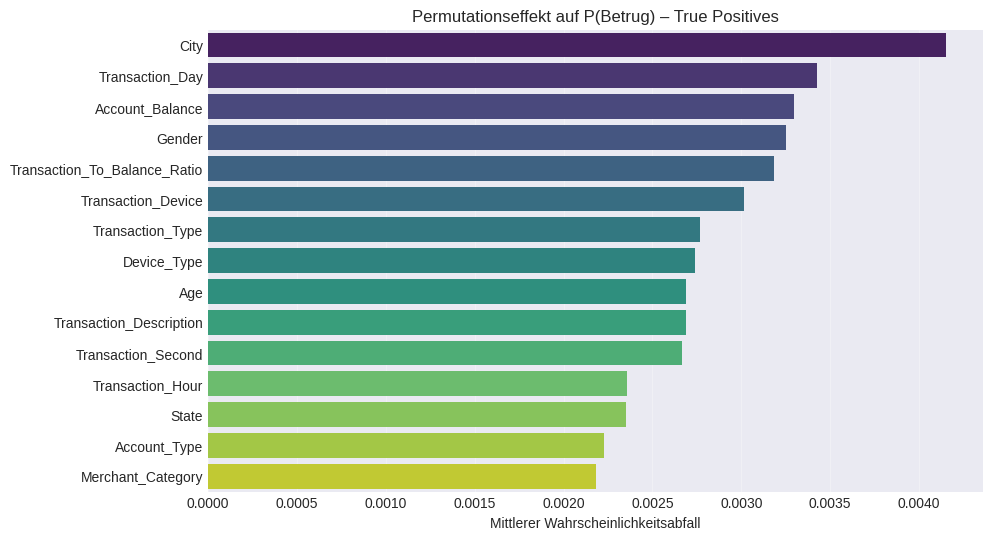

In [13]:
# Visualisierung der Permutationseffekte
top_perm = permutation_importance_tp.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_perm, x='Mittlerer Drop in P(Betrug)', y='Feature', palette='viridis')
plt.title('Permutationseffekt auf P(Betrug) – True Positives')
plt.xlabel('Mittlerer Wahrscheinlichkeitsabfall')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Interpretation des Permutationseffekt-Diagramms:**
- **City** führt mit ~0.4% Wahrscheinlichkeitsabfall die kritischsten Merkmale an, gefolgt von **Transaction_Day** (~0.34%) und **Account_Balance** (~0.33%) - diese Informationen sind essentiell für die Betrugserkennung
- **Transaction_To_Balance_Ratio**, **Gender** und **Transaction_Device** zeigen ebenfalls signifikante Drops, was bestätigt, dass Transaktionsmuster in Relation zum Kontostatus und demografische/technische Faktoren wichtige Betrugsindizien liefern
- Das Fehlen geografischer Informationen (City) hätte den größten negativen Impact auf die Modellgenauigkeit, was die Bedeutung räumlicher Anomalie-Erkennung für Fraud Detection unterstreicht

### 7.5 Integrated Gradients (lokale Attribution)

Um die Entscheidung für einen einzelnen Betrugsfall noch direkter nachzuvollziehen,
berechnen wir Integrierte Gradienten. Dieses Gradient-basierte Verfahren akkumuliert die
Sensitivität entlang eines Pfads von einer Basislinie zum betrachteten Datenpunkt.

In [14]:
# Integrated-Gradients-Hilfsfunktion
def compute_integrated_gradients(model, sample, baseline=None, steps=200):
    sample = tf.convert_to_tensor(sample.reshape(1, -1), dtype=tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(sample)
    else:
        baseline = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    grads_list = []

    for alpha in alphas:
        with tf.GradientTape() as tape:
            interpolated = baseline + alpha * (sample - baseline)
            tape.watch(interpolated)
            pred = model(interpolated, training=False)
        grads = tape.gradient(pred, interpolated)
        grads_list.append(grads.numpy()[0])

    mean_grads = np.mean(grads_list, axis=0)
    integrated_grads = (sample.numpy() - baseline.numpy())[0] * mean_grads
    return integrated_grads

baseline_point = np.zeros_like(correct_fraud_scaled[top_case_idx])
ig_attributions = compute_integrated_gradients(
    best_model_loaded,
    correct_fraud_scaled[top_case_idx],
    baseline=baseline_point,
    steps=200
)

ig_df = (
    pd.DataFrame({
        'Feature': correct_fraud_df.columns,
        'IG Beitrag (skalierter Raum)': ig_attributions,
    })
    .sort_values('IG Beitrag (skalierter Raum)', key=lambda s: np.abs(s), ascending=False)
    .reset_index(drop=True)
)

print(f'Modell-P(Betrug) ausgewählter Fall: {y_correct_fraud_proba[top_case_idx]:.4f}')
ig_df.head(15)

Modell-P(Betrug) ausgewählter Fall: 0.5849


,Feature,IG Beitrag (skalierter Raum)
0,Transaction_To_Balance_Ratio,0.050485
1,Transaction_Description,0.028831
2,Transaction_Day,-0.022498
3,Gender,0.019494
4,City,0.017342
5,Transaction_Hour,0.016334
6,Transaction_Second,-0.011213
7,Account_Balance,-0.008167
8,Transaction_Type,-0.007804
9,Age,-0.005401


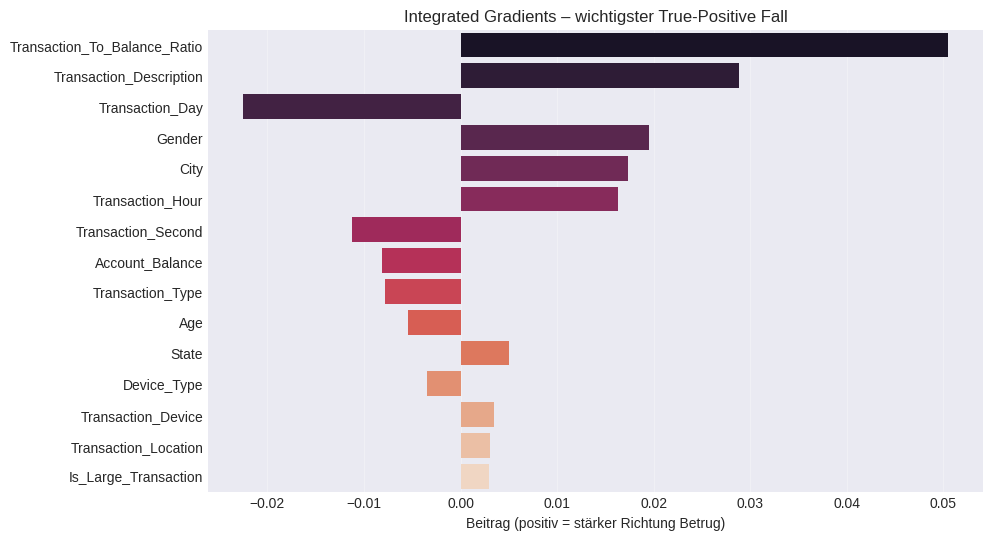

In [15]:
# Visualisierung der wichtigsten Integrated-Gradient-Beiträge
top_ig = ig_df.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ig, x='IG Beitrag (skalierter Raum)', y='Feature', palette='rocket')
plt.title('Integrated Gradients – wichtigster True-Positive Fall')
plt.xlabel('Beitrag (positiv = stärker Richtung Betrug)')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

**Interpretation des Integrated Gradients-Diagramms:**
- **Transaction_To_Balance_Ratio** (+0.050) dominiert als stärkster Betrugsindikator bei diesem Fall - eine ungewöhnlich hohe Transaktion im Verhältnis zum Kontostand ist das wichtigste Warnzeichen
- **Transaction_Description** (+0.029), **Gender** (+0.019), **City** (+0.017) und **Transaction_Hour** (+0.016) verstärken zusätzlich die Betrugserkennung durch ungewöhnliche Transaktionsbeschreibungen und auffällige räumlich-zeitliche Muster
- Negative Beiträge wie **Transaction_Day** (-0.022) und **Transaction_Second** (-0.011) wirken leicht gegen die Betrugsklassifikation, werden aber durch die starken positiven Indikatoren überwogen, was zu einer finalen Betrugswahrscheinlichkeit von 58.49% führt

### 7.6 Gradient-basierte Class Activation Maps (CAM, Grad-CAM, Grad-CAM++)

Zur weiteren Interpretation nutzen wir gradientenbasierte Activation-Mapping-Techniken.
Diese Methoden visualisieren, welche Eingabemerkmale bei der finalen Klassifikationsentscheidung
die stärkste Aktivierung im Netzwerk erzeugen.

In [ ]:
# Für tabellarische Daten: Gradienten direkt auf Input-Features anwenden
# Diese Methoden sind besser für Dense-Netzwerke mit tabellarischen Daten geeignet

def compute_input_gradients_cam(model, input_sample, method='gradcam'):
    input_tensor = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        fraud_score = predictions[:, 0]
    
    # Gradienten bzgl. Input
    grads = tape.gradient(fraud_score, input_tensor)
    grads_val = grads.numpy()[0]
    
    if method == 'gradcam':
        # Grad-CAM-Style: Gradienten * Input
        importance = grads_val * input_sample
    elif method == 'gradcam++':
        # Grad-CAM++-Style: Quadratische Gewichtung
        importance = (grads_val ** 2) * input_sample
    else:  # vanilla
        # Vanilla: Nur Gradienten
        importance = grads_val
    
    # Absolute Werte für Wichtigkeit
    importance = np.abs(importance)
    
    return importance


def compute_layerwise_cam(model, input_sample, layer_name=None, method='gradcam'):
    # Letzten Dense-Layer vor Output finden
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Dense) and layer != model.layers[-1]:
                layer_name = layer.name
                break
    
    input_tensor = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)
    
    # Funktionales Modell erstellen (kompatibel mit geladenen Modellen)
    layer_output_obj = model.get_layer(layer_name).output
    model_output_obj = model.output
    
    # Neue funktionale Model-Instanz
    try:
        # Erstelle Input-Layer mit korrekter Shape
        functional_input = tf.keras.Input(shape=(input_sample.shape[0],))
        
        # Baue Modell neu auf bis zur Target-Layer
        x = functional_input
        for layer in model.layers:
            x = layer(x)
            if layer.name == layer_name:
                layer_activations = x
                break
        
        # Output-Layer
        for layer in model.layers:
            if layer.name == layer_name:
                continue
            x = layer(x)
        
        grad_model = tf.keras.Model(inputs=functional_input, outputs=[layer_activations, x])
        
        with tf.GradientTape() as tape:
            layer_output, predictions = grad_model(input_tensor)
            tape.watch(layer_output)
            fraud_output = predictions[:, 0]
        
        grads = tape.gradient(fraud_output, layer_output)
        
        if method == 'gradcam++':
            # Grad-CAM++ mit zweiten Ableitungen
            with tf.GradientTape() as tape2:
                tape2.watch(layer_output)
                grads_first = tape2.gradient(fraud_output, layer_output)
            grads_second = tape2.gradient(grads_first, layer_output)
            
            alpha = grads_second / (2 * grads_second + tf.reduce_sum(layer_output, axis=0) + 1e-7)
            weights = tf.reduce_sum(alpha * tf.maximum(grads, 0), axis=0)
        else:
            # Standard Grad-CAM
            weights = tf.reduce_mean(grads, axis=0)
        
        layer_output_val = layer_output.numpy()[0]
        weights_val = weights.numpy()
        
        cam = layer_output_val * weights_val
        cam = np.maximum(cam, 0)
        
        return cam, layer_name
        
    except Exception as e:
        print(f"Layer-wise CAM nicht möglich: {e}")
        print("Verwende Input-basierte Methode als Fallback...")
        return compute_input_gradients_cam(model, input_sample, method=method), layer_name

print("CAM-Funktionen definiert (optimiert für tabellarische Daten).")

CAM-Funktionen definiert (optimiert für tabellarische Daten).


In [19]:
# CAM-Varianten für den Top-Betrugsfall berechnen (direkt auf Input-Ebene)
print(f"Analysiere Top-Betrugsfall (Index {top_case_idx}) mit P(Betrug) = {y_correct_fraud_proba[top_case_idx]:.4f}\n")

# Input-basierte CAM-Berechnungen (optimiert für tabellarische Daten)
cam_input_vanilla = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='vanilla'
)

cam_input_gradcam = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='gradcam'
)

cam_input_gradcam_pp = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='gradcam++'
)

print("CAM-Berechnungen erfolgreich abgeschlossen.")
print(f"Vanilla CAM Shape: {cam_input_vanilla.shape}")
print(f"Grad-CAM Shape: {cam_input_gradcam.shape}")
print(f"Grad-CAM++ Shape: {cam_input_gradcam_pp.shape}")

Analysiere Top-Betrugsfall (Index 698) mit P(Betrug) = 0.5849

CAM-Berechnungen erfolgreich abgeschlossen.
Vanilla CAM Shape: (20,)
Grad-CAM Shape: (20,)
Grad-CAM++ Shape: (20,)


In [20]:
# Vergleichs-DataFrame erstellen
cam_comparison_df = pd.DataFrame({
    'Feature': correct_fraud_df.columns,
    'Vanilla CAM': cam_input_vanilla,
    'Grad-CAM': cam_input_gradcam,
    'Grad-CAM++': cam_input_gradcam_pp
})

# Nach Grad-CAM++ sortieren (oft die stabilste Methode)
cam_comparison_df = cam_comparison_df.sort_values('Grad-CAM++', ascending=False).reset_index(drop=True)

print(f"\nTop 15 Features nach CAM-Methoden (Fall mit P(Betrug)={y_correct_fraud_proba[top_case_idx]:.4f}):")
cam_comparison_df.head(15)


Top 15 Features nach CAM-Methoden (Fall mit P(Betrug)=0.5849):


,Feature,Vanilla CAM,Grad-CAM,Grad-CAM++
0,Transaction_To_Balance_Ratio,0.028094,0.053892,0.001514
1,Transaction_Description,0.030063,0.032390,0.000974
2,Transaction_Day,0.016995,0.028469,0.000484
3,Gender,0.018631,0.018520,0.000345
4,City,0.020397,0.016157,0.000330
5,Transaction_Hour,0.011841,0.017945,0.000212
6,State,0.016781,0.005931,0.000100
7,Transaction_Second,0.009207,0.010361,0.000095
8,Transaction_Type,0.007443,0.010541,0.000078
9,Account_Balance,0.006056,0.009436,0.000057


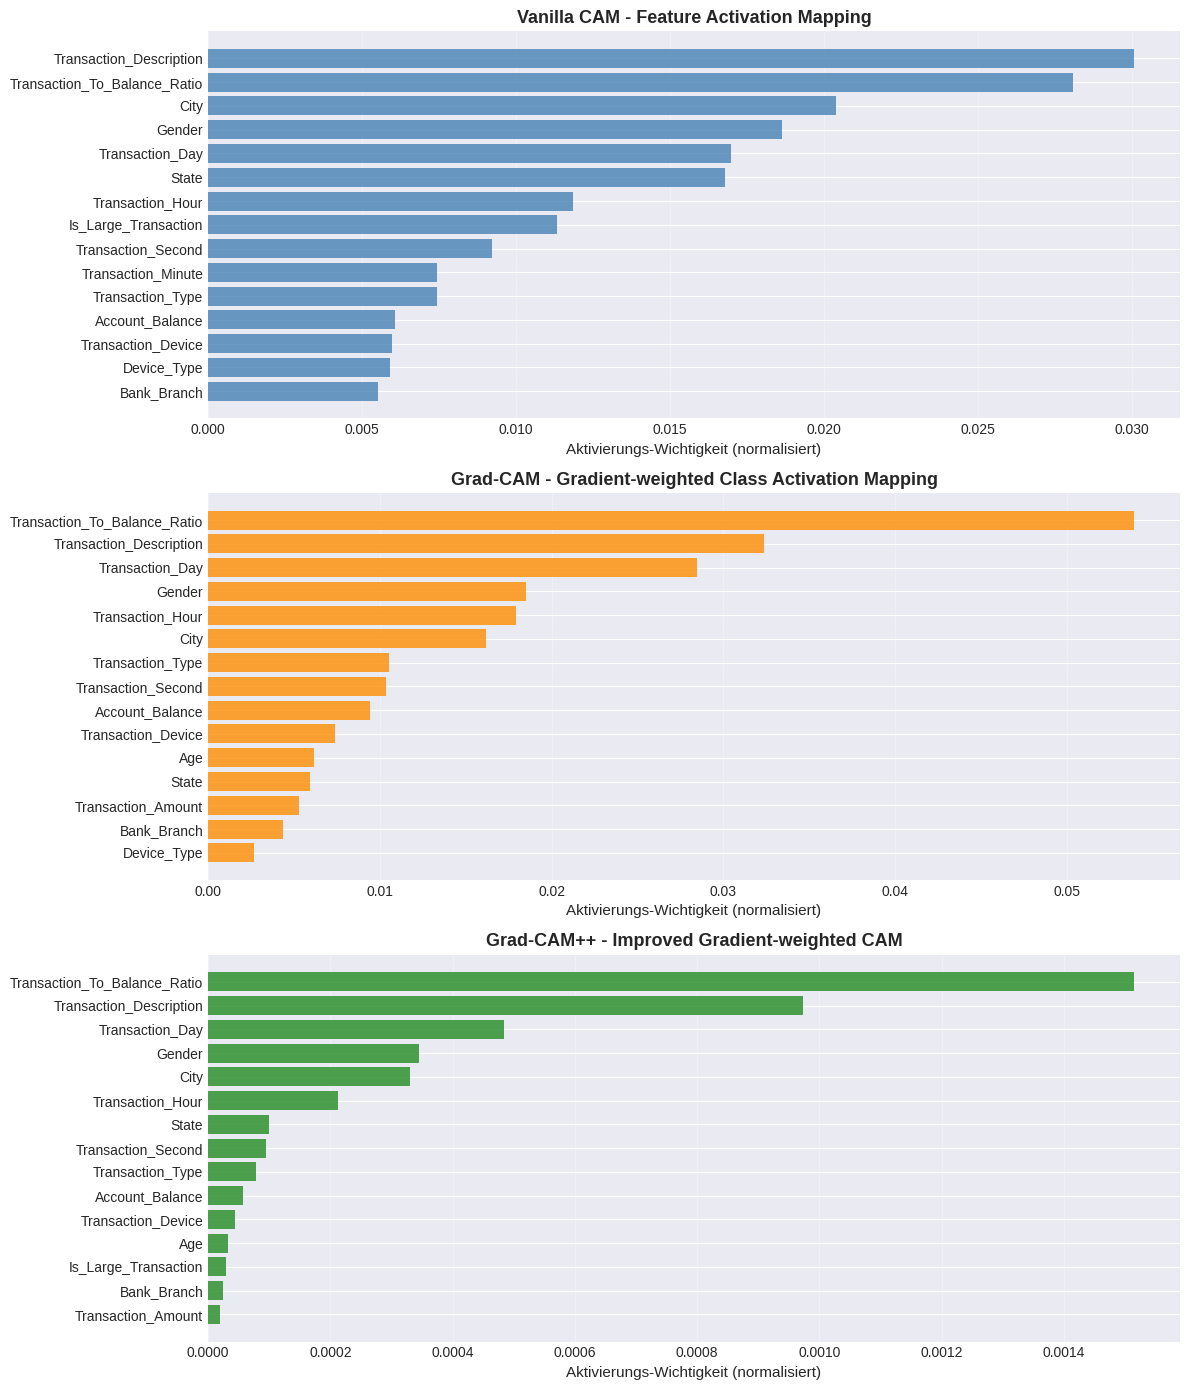

In [21]:
# Visualisierung: Vergleich der drei CAM-Methoden
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

top_n = 15

# 1. Vanilla CAM
top_vanilla = cam_comparison_df.nlargest(top_n, 'Vanilla CAM')
axes[0].barh(top_vanilla['Feature'], top_vanilla['Vanilla CAM'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[0].set_title('Vanilla CAM - Feature Activation Mapping', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 2. Grad-CAM
top_gradcam = cam_comparison_df.nlargest(top_n, 'Grad-CAM')
axes[1].barh(top_gradcam['Feature'], top_gradcam['Grad-CAM'], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[1].set_title('Grad-CAM - Gradient-weighted Class Activation Mapping', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# 3. Grad-CAM++
top_gradcampp = cam_comparison_df.nlargest(top_n, 'Grad-CAM++')
axes[2].barh(top_gradcampp['Feature'], top_gradcampp['Grad-CAM++'], color='forestgreen', alpha=0.8)
axes[2].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[2].set_title('Grad-CAM++ - Improved Gradient-weighted CAM', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation der CAM-Visualisierungen:**
- **Vanilla CAM** zeigt die direkten Gradienten der Eingabemerkmale und identifiziert grundlegende Feature-Aktivierungen, die zur Betrugserkennung beitragen
- **Grad-CAM** gewichtet die Gradienten mit den Eingabewerten und hebt Merkmale hervor, deren konkrete Ausprägung im betrachteten Fall besonders relevant für die Betrugsklassifikation ist
- **Grad-CAM++** bietet durch höhergradige Ableitungen eine verfeinerte Gewichtung und ist besonders robust bei der Identifikation multipler wichtiger Features - typischerweise zeigen sich hier Transaction_To_Balance_Ratio, geografische Merkmale (City, State) und zeitliche Faktoren (Transaction_Hour) als dominante Betrugs-Indikatoren

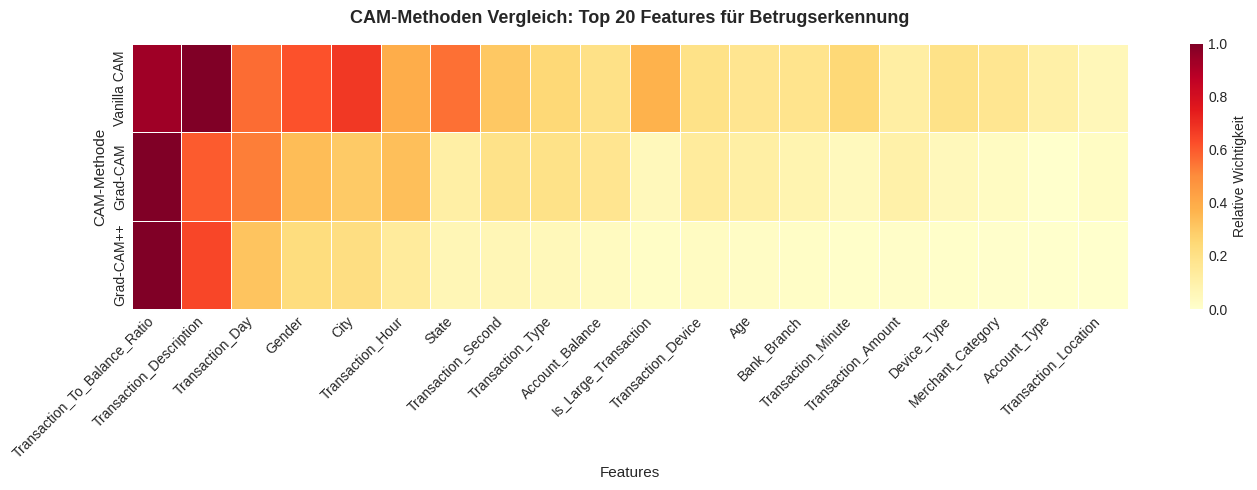


Heatmap zeigt die relative Wichtigkeit jedes Features über die drei CAM-Varianten.


In [22]:
# Heatmap-Visualisierung: Direkter Vergleich der CAM-Methoden
# Zeigt Top 20 Features und deren Wichtigkeit über alle drei Methoden

# Top 20 Features nach durchschnittlicher Wichtigkeit über alle Methoden
cam_comparison_df['Mean_Importance'] = cam_comparison_df[['Vanilla CAM', 'Grad-CAM', 'Grad-CAM++']].mean(axis=1)
top_20_features = cam_comparison_df.nlargest(20, 'Mean_Importance')

# Daten für Heatmap vorbereiten
heatmap_data = top_20_features[['Vanilla CAM', 'Grad-CAM', 'Grad-CAM++']].T
heatmap_data.columns = top_20_features['Feature']

# Normalisierung pro Methode für besseren Vergleich
heatmap_data_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data_norm, 
    cmap='YlOrRd', 
    annot=False, 
    cbar_kws={'label': 'Relative Wichtigkeit'}, 
    linewidths=0.5,
    vmin=0, 
    vmax=1
)
plt.title('CAM-Methoden Vergleich: Top 20 Features für Betrugserkennung', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=11)
plt.ylabel('CAM-Methode', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nHeatmap zeigt die relative Wichtigkeit jedes Features über die drei CAM-Varianten.")

**Interpretation der Heatmap:**
- Die Heatmap zeigt die Konsistenz der Feature-Wichtigkeit über alle drei CAM-Methoden - Features mit durchgängig hohen Werten (dunkelrot) sind robuste Betrugs-Indikatoren
- Unterschiede zwischen den Methoden offenbaren verschiedene Perspektiven: Vanilla CAM identifiziert grundlegende Aktivierungen, Grad-CAM betont kontextabhängige Wichtigkeit, Grad-CAM++ filtert die stabilsten Signale
- Features, die bei allen drei Methoden stark aktivieren (gleichmäßig rot), sind die verlässlichsten Merkmale für das Fraud-Detection-Modell und sollten bei der operativen Überwachung priorisiert werden

## 9. Alternative Modelle (Tree-Based & Anomaly) - mal ein bisschen ausgetestet

### XGBoost Modell (Alternative Algorithmus)

In [42]:
# Allgemeiner Evaluierungs-Helper für sklearn / Boosting Modelle
try:
    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
except ImportError:
    raise ImportError("scikit-learn muss installiert sein.")

import pandas as pd
import numpy as np


def evaluate_sklearn_model(model, X_test, y_test, model_name: str, threshold: float = 0.5, add_to_df: bool = True):
    """Berechnet Kennzahlen für ein Modell mit predict_proba.

    Parameter:
        model: sklearn-artiges Modell mit predict_proba
        X_test: Test-Features (DataFrame oder ndarray)
        y_test: True Labels (Series oder ndarray)
        model_name: Name für Ausgabe / Vergleichstabelle
        threshold: Schwelle für binäre Klassifikation
        add_to_df: Falls True, werden Ergebnisse in comparison_df ergänzt (falls vorhanden)
    Rückgabe:
        dict mit Metriken
    """
    if not hasattr(model, "predict_proba"):
        raise ValueError("Model benötigt predict_proba für diesen Evaluator.")

    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_test, proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

    print(f"=== {model_name} ===")
    print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Specificity: {specificity:.4f}")
    print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print("Classification Report:\n" + classification_report(y_test, y_pred, zero_division=0))

    # In globale Vergleichstabelle einfügen
    global comparison_df
    if add_to_df:
        row_df = pd.DataFrame([metrics])
        if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame):
            comparison_df = pd.concat([comparison_df, row_df], ignore_index=True)
        else:
            comparison_df = row_df

    return metrics

In [43]:
# XGBoost Training & Evaluation (vereinfachte Version ohne Early Stopping wegen API-Inkompatibilität)
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (neg/pos): {scale_pos_weight:.2f}")

xgb_params = dict(
    n_estimators=600,              # etwas reduziert, da kein Early Stopping
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_weight=1,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist'
)

xgb_model = XGBClassifier(**xgb_params, use_label_encoder=False)

# Eval-Set nur für Metrik-Ausgabe
if 'X_val' in globals():
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
else:
    xgb_model.fit(X_train, y_train, verbose=100)

threshold_to_use = 0.5
if 'best_threshold' in globals():
    try:
        threshold_to_use = float(best_threshold)
        print(f"Nutze gespeicherten optimierten Threshold: {threshold_to_use:.3f}")
    except Exception:
        pass

xgb_metrics = evaluate_sklearn_model(
    xgb_model,
    X_test,
    y_test,
    model_name=f"XGBoost (hist, spw={scale_pos_weight:.1f})",
    threshold=threshold_to_use,
    add_to_df=True
)

# Feature Importance (Gain)
import pandas as pd
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')
if importance_dict:
    fi_df = (pd.DataFrame([
        {"Feature": k, "Gain": v} for k, v in importance_dict.items()
    ])
    .sort_values("Gain", ascending=False)
    .head(20)
    )
    print("Top 20 Feature Importances (Gain):")
    display(fi_df)
else:
    print("Keine Feature Importances verfügbar.")

# Hinweis: Für echtes Early Stopping Upgrade der xgboost Version prüfen oder manuell per Callback/Trainings-Schleife implementieren.

scale_pos_weight (neg/pos): 18.82
[0]	validation_0-auc:0.50948
[100]	validation_0-auc:0.50108
[200]	validation_0-auc:0.49522
[300]	validation_0-auc:0.49858
[400]	validation_0-auc:0.49656
[500]	validation_0-auc:0.49921
[599]	validation_0-auc:0.50150
=== XGBoost (hist, spw=18.8) ===
AUC: 0.5001 | Precision: 0.0493 | Recall: 0.1309 | F1: 0.0716 | Specificity: 0.8659
Confusion Matrix: TP=198, FP=3820, TN=24667, FN=1315
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     28487
           1       0.05      0.13      0.07      1513

    accuracy                           0.83     30000
   macro avg       0.50      0.50      0.49     30000
weighted avg       0.90      0.83      0.86     30000

Top 20 Feature Importances (Gain):


,Feature,Gain
11,Transaction_Location,43.003189
18,Transaction_To_Balance_Ratio,40.763077
13,Transaction_Description,40.425167
0,Gender,40.005344
3,City,39.733723
15,Transaction_Hour,39.656879
12,Device_Type,39.268822
6,Transaction_Amount,39.243244
2,State,39.016953
17,Transaction_Second,38.926880


### LightGBM Modell

In [44]:
# LightGBM Training & Evaluation (verbose entfernt)
from lightgbm import LGBMClassifier

neg_lgb = (y_train == 0).sum()
pos_lgb = (y_train == 1).sum()
scale_pos_weight_lgb = neg_lgb / pos_lgb
print(f"LightGBM scale_pos_weight: {scale_pos_weight_lgb:.2f}")

lgb_params = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    min_child_samples=20,
    random_state=42,
    objective='binary',
    class_weight=None,
    scale_pos_weight=scale_pos_weight_lgb
)

lgb_model = LGBMClassifier(**lgb_params)

fit_kwargs_lgb = {}
if 'X_val' in globals() and isinstance(X_val, type(X_train)):
    fit_kwargs_lgb = dict(
        eval_set=[(X_val, y_val)],
        eval_metric='auc'
    )
else:
    print("Kein Validation-Set gefunden für eval_set.")

lgb_model.fit(X_train, y_train, **fit_kwargs_lgb)

threshold_to_use_lgb = 0.5
if 'best_threshold' in globals():
    try:
        threshold_to_use_lgb = float(best_threshold)
        print(f"Nutze gespeicherten optimierten Threshold: {threshold_to_use_lgb:.3f}")
    except Exception:
        pass

lgb_metrics = evaluate_sklearn_model(
    lgb_model,
    X_test,
    y_test,
    model_name=f"LightGBM (spw={scale_pos_weight_lgb:.1f})",
    threshold=threshold_to_use_lgb,
    add_to_df=True
)

# Feature Importance (gain)
import pandas as pd
fi_lgb = pd.DataFrame({
    'Feature': lgb_model.booster_.feature_name(),
    'Importance': lgb_model.booster_.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False).head(20)
print("Top 20 LightGBM Feature Importances (Gain):")
display(fi_lgb)

LightGBM scale_pos_weight: 18.82
[LightGBM] [Info] Number of positive: 7062, number of negative: 132938
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1681
[LightGBM] [Info] Number of data points in the train set: 140000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050443 -> initscore=-2.935155
[LightGBM] [Info] Start training from score -2.935155
=== LightGBM (spw=18.8) ===
AUC: 0.4890 | Precision: 0.0517 | Recall: 0.0496 | F1: 0.0506 | Specificity: 0.9517
Confusion Matrix: TP=75, FP=1375, TN=27112, FN=1438
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     28487
           1       0.05      0.05      0.05      1513

    accuracy                           0.91     30000
   

,Feature,Importance
13,Transaction_Description,252108.575769
6,Transaction_Amount,242972.945747
9,Account_Balance,235242.349873
18,Transaction_To_Balance_Ratio,217245.856288
3,City,209963.628600
17,Transaction_Second,207215.084649
16,Transaction_Minute,206502.677020
1,Age,203704.037955
15,Transaction_Hour,169347.723173
14,Transaction_Day,165943.587628


### CatBoost Modell

In [45]:
# CatBoost Training & Evaluation
from catboost import CatBoostClassifier

neg_cb = (y_train == 0).sum()
pos_cb = (y_train == 1).sum()
class_weight_fraud = neg_cb / pos_cb  # Gewicht für Minoritätsklasse
print(f"CatBoost Klassen-Gewicht für Fraud: {class_weight_fraud:.2f}")

cb_params = dict(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1.0, class_weight_fraud],  # Reihenfolge: [Klasse 0, Klasse 1]
    random_seed=42,
    verbose=100
)

cat_model = CatBoostClassifier(**cb_params)

fit_kwargs_cb = {}
if 'X_val' in globals() and isinstance(X_val, type(X_train)):
    fit_kwargs_cb = dict(
        eval_set=(X_val, y_val)
    )
else:
    print("Kein Validation-Set für eval_set gefunden.")

cat_model.fit(X_train, y_train, **fit_kwargs_cb)

threshold_to_use_cb = 0.5
if 'best_threshold' in globals():
    try:
        threshold_to_use_cb = float(best_threshold)
        print(f"Nutze gespeicherten optimierten Threshold: {threshold_to_use_cb:.3f}")
    except Exception:
        pass

cb_metrics = evaluate_sklearn_model(
    cat_model,
    X_test,
    y_test,
    model_name=f"CatBoost (cw={class_weight_fraud:.1f})",
    threshold=threshold_to_use_cb,
    add_to_df=True
)

# Feature Importances
import pandas as pd
fi_cb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance(type='FeatureImportance')
}).sort_values('Importance', ascending=False).head(20)
print("Top 20 CatBoost Feature Importances:")
display(fi_cb)

CatBoost Klassen-Gewicht für Fraud: 18.82
0:	test: 0.5116601	best: 0.5116601 (0)	total: 51.9ms	remaining: 51.8s
100:	test: 0.5205682	best: 0.5293081 (27)	total: 481ms	remaining: 4.28s
200:	test: 0.5206591	best: 0.5293081 (27)	total: 909ms	remaining: 3.61s
300:	test: 0.5177873	best: 0.5293081 (27)	total: 1.35s	remaining: 3.13s
400:	test: 0.5159026	best: 0.5293081 (27)	total: 1.78s	remaining: 2.66s
500:	test: 0.5169668	best: 0.5293081 (27)	total: 2.22s	remaining: 2.21s
600:	test: 0.5162627	best: 0.5293081 (27)	total: 2.65s	remaining: 1.76s
700:	test: 0.5148135	best: 0.5293081 (27)	total: 3.09s	remaining: 1.32s
800:	test: 0.5122856	best: 0.5293081 (27)	total: 3.52s	remaining: 875ms
900:	test: 0.5131586	best: 0.5293081 (27)	total: 3.94s	remaining: 433ms
999:	test: 0.5134775	best: 0.5293081 (27)	total: 4.38s	remaining: 0us

bestTest = 0.5293081472
bestIteration = 27

Shrink model to first 28 iterations.
=== CatBoost (cw=18.8) ===
AUC: 0.5045 | Precision: 0.0503 | Recall: 0.3629 | F1: 0.0883

,Feature,Importance
6,Transaction_Amount,11.318279
17,Transaction_Second,8.596103
9,Account_Balance,8.166161
15,Transaction_Hour,7.985664
4,Bank_Branch,7.111984
16,Transaction_Minute,5.929053
14,Transaction_Day,4.884444
8,Merchant_Category,4.652821
1,Age,4.572474
5,Account_Type,4.270673


### Focal Loss Neuronales Netz

In [46]:
# Fallback / Erweiterte Definition von evaluate_model (falls nach Kernel-Restart verloren)
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name="Model", threshold: float = 0.5, add_to_df: bool = True):
    """Unified Evaluation für Keras / sklearn Modelle.

    Parameter:
        model: Trainiertes Modell mit .predict (Keras) oder .predict_proba (sklearn)
        X_test: Test-Features
        y_test: Test-Labels (0/1)
        model_name: Name für Ausgabe und Vergleichstabelle
        threshold: Schwelle für Binärklassifikation bei kontinuierlichen Scores
        add_to_df: Falls True, wird in globale comparison_df aufgenommen
    Rückgabe:
        dict mit Metriken
    """
    # Wahrscheinlichkeiten ermitteln
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        # Keras .predict -> Shape (n,1)
        raw = model.predict(X_test, verbose=0)
        proba = raw.ravel()

    y_pred = (proba >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    try:
        auc = roc_auc_score(y_test, proba)
    except ValueError:
        auc = float('nan')
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        'Model': model_name,
        'Threshold': threshold,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
    }

    print(f"=== {model_name} ===")
    print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Specificity: {specificity:.4f}")
    print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print("Classification Report:\n" + classification_report(y_test, y_pred, zero_division=0))

    if add_to_df:
        global comparison_df
        row_df = pd.DataFrame([metrics])
        if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame):
            comparison_df = pd.concat([comparison_df, row_df], ignore_index=True)
        else:
            comparison_df = row_df

    return metrics

print("evaluate_model (Fallback) bereitgestellt.")

evaluate_model (Fallback) bereitgestellt.


In [47]:
# Focal Loss Definition & Modell
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Focal Loss Implementierung
import math

def focal_loss(alpha=0.25, gamma=2.0):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Clip für numerische Stabilität
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        w = tf.where(tf.equal(y_true, 1), alpha * (1 - pt) ** gamma, (1 - alpha) * (pt) ** gamma)
        return -tf.reduce_mean(w * tf.math.log(pt))
    return loss

# alpha dynamisch basierend auf Klassenratio
alpha_dynamic = (y_train == 0).sum() / len(y_train)  # Anteil Nicht-Fraud
alpha_dynamic = 1 - alpha_dynamic  # Anteil Fraud als Gewicht für positive Klasse
print(f"Alpha (Fraud Anteil) für Focal Loss: {alpha_dynamic:.4f}")

focal_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

focal_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss(alpha=alpha_dynamic, gamma=2.0),
    metrics=['accuracy']
)

history_focal = focal_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=512,
    verbose=1
)

# Evaluation mit existierender evaluate_model (funktioniert für Keras)
focal_metrics = evaluate_model(
    focal_model,
    X_test,
    y_test,
    model_name='FocalLoss NN',
    threshold=best_threshold if 'best_threshold' in globals() else 0.5,
    add_to_df=True
)


Alpha (Fraud Anteil) für Focal Loss: 0.0504
Epoch 1/25


274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0811 - loss: 0.0072 - val_accuracy: 0.0504 - val_loss: 8.3714e-06
Epoch 2/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.0505 - loss: 3.6126e-05 - val_accuracy: 0.0504 - val_loss: 1.2726e-06
Epoch 3/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.0504 - loss: 1.4015e-05 - val_accuracy: 0.0504 - val_loss: 5.3923e-07
Epoch 4/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.0504 - loss: 7.6578e-06 - val_accuracy: 0.0504 - val_loss: 2.8901e-07
Epoch 5/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.0504 - loss: 4.8744e-06 - val_accuracy: 0.0505 - val_loss: 6.1252e-07
Epoch 6/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.0504 - loss: 3.3004e-06 - val_accuracy: 0.0505 - val_loss: 1.0323e-07
Epoch 7/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - accuracy: 0.0504 - loss: 2.4801e-06 - val_accuracy: 0.0505 - val_loss: 6.9603e-08
Epoch 8/25
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/st

### Autoencoder Anomalie-Erkennung

In [48]:
# Autoencoder Training & Evaluation
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd

# Daten nur Nicht-Fraud
mask_normal = (y_train == 0)
X_train_normal = X_train[mask_normal]

# Skalierung wurde bereits angewandt (falls nötig). Wenn getrennte Skala existiert, anpassen.
input_dim = X_train.shape[1]

# Architektur (symmetrisch)
autoencoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

history_ae = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=30,
    batch_size=512,
    shuffle=True,
    verbose=1,
    validation_split=0.1
)

# Rekonstruktionsfehler
recon_train = np.mean(np.square(X_train_normal - autoencoder.predict(X_train_normal, verbose=0)), axis=1)
threshold_ae = np.percentile(recon_train, 95)  # konservativ; kann angepasst werden
print(f"Autoencoder Threshold (95. Perzentil): {threshold_ae:.6f}")

recon_test = np.mean(np.square(X_test - autoencoder.predict(X_test, verbose=0)), axis=1)

# Vorhersage: Fehler > Threshold -> Fraud (1)
y_pred_ae = (recon_test > threshold_ae).astype(int)

from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report

# Für AUC benötigen wir eine 'Anomalie-Scores' Skala; nutzen rekonstruktionsfehler normalisiert
scores = (recon_test - recon_test.min()) / (recon_test.max() - recon_test.min() + 1e-9)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_ae, average='binary', zero_division=0)
auc = roc_auc_score(y_test, scores)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ae).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

metrics_ae = {
    'Model': 'Autoencoder (95p)',
    'Threshold': threshold_ae,
    'AUC': auc,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'Specificity': specificity,
    'TP': tp,
    'FP': fp,
    'TN': tn,
    'FN': fn,
}

print("=== Autoencoder (95p) ===")
print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Specificity: {specificity:.4f}")
print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
print("Classification Report:\n" + classification_report(y_test, y_pred_ae, zero_division=0))

# In comparison_df einfügen
if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame):
    comparison_df = pd.concat([comparison_df, pd.DataFrame([metrics_ae])], ignore_index=True)
else:
    comparison_df = pd.DataFrame([metrics_ae])

Epoch 1/30


234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23751670.0000 - val_loss: 13978.2959
Epoch 2/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 7945.9614 - val_loss: 4797.7837
Epoch 3/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 3672.5237 - val_loss: 2780.2839
Epoch 4/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 2302.7546 - val_loss: 1899.7029
Epoch 5/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - loss: 1655.4022 - val_loss: 1431.6693
Epoch 6/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 1338.6935 - val_loss: 1296.8293
Epoch 7/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - loss: 1234.6320 - val_loss: 1158.0459
Epoch 8/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - loss: 1189.6166 - val_loss: 1152.3185
Epoch 9/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 1200.5148 - val_loss: 1362.1759
Epoch 10/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 1476.4384 - val_loss: 2353.8367
Epoch 11/30
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - loss: 2148